<a href="https://colab.research.google.com/github/oszavla/Dirac-Schwarz/blob/main/Solusi_Eigen_dengan_Metode_Matching_Cohen_Soffel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Solusi Persamaan Dirac dalam Latar Belakang Metrik Eksterior Schwarzschild


In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')
# Font Style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['mathtext.fontset'] = 'cm'

Mounted at /content/drive


##Nilai Eigen Riil dan Fungsi Eigen *Quasi-Bound State* (QBS)

### Domain Komputasional Koordinat Radial Standar

Proses ini mengunakan syarat batas $G(2\alpha')=F(2\alpha')=0$ dan $G(\infty)=F(\infty)=0$

Persamaan radial yang digunakan adalah
\begin{align*}
\frac{\mathrm dG}{\mathrm d\rho} &= -\frac{1}{\sqrt{f}}\frac{\kappa}{\rho}G + \frac{1}{\sqrt{f}}\left(1 + \frac{\epsilon}{\sqrt{f}}\right)F,  \\
\frac{\mathrm dF}{\mathrm d\rho} &= +\frac{1}{\sqrt{f}}\frac{\kappa}{\rho}F + \frac{1}{\sqrt{f}}\left(1 - \frac{\epsilon}{\sqrt{f}}\right)G,
\end{align*}



Bracket error : kappa = -2, rho_match = 2.02500: f(a) and f(b) must have different signs
Convergent for kappa=-2, rho_m = 2.0487 epsilon=0.910079


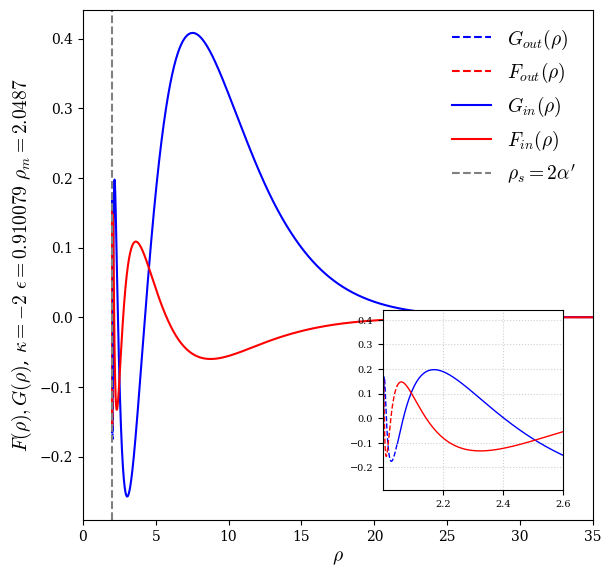

Convergent for kappa=2, rho_m = 2.0250 epsilon=0.864715


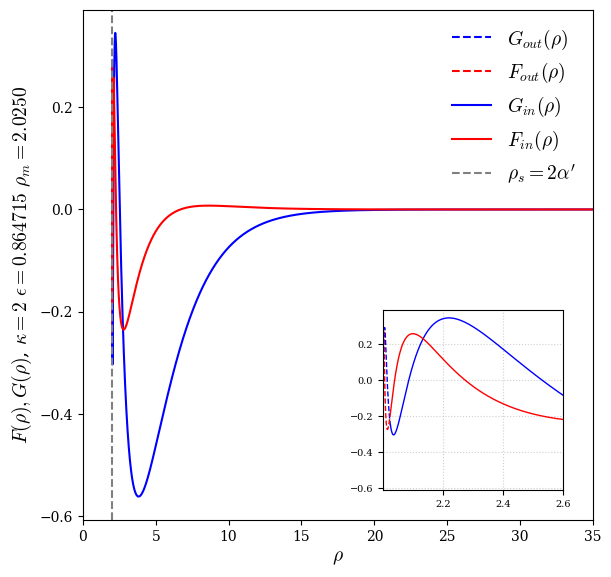


---Energy Mismatch Calculation Details (DataFrame) ---


,kappa,epsilon,G_out,F_out,G_in,F_in,ΔG,rho_m
0,-2,0.85000000,-9.6882e-06,-9.2742e-06,1.2692e+129,7.7871e+128,5.4279e-06,2.02500
1,-2,0.99980000,-1.0726e-05,1.0284e-05,-6.4311e-05,1.1787e-05,4.5384e-05,2.02500
2,-2,0.85000000,-1.5422e-05,4.7084e-06,1.5504e+129,-7.4742e+128,-5.6552e-06,2.04870
3,-2,0.99980000,7.8468e-06,1.0316e-05,-9.2837e-06,5.5969e-05,9.5579e-06,2.04870
4,-2,0.90568534,-9.4861e-06,1.1340e-05,-2.8318e+100,6.7890e+100,-4.7561e-06,2.04870
5,-2,0.95274267,-9.2583e-07,1.2984e-05,2.2846e+67,-1.2040e+67,2.3711e-05,2.04870
6,-2,0.91354736,-8.2017e-06,1.1907e-05,-1.0349e+96,9.4212e+95,4.8787e-06,2.04870
7,-2,0.90956634,-8.8624e-06,1.1634e-05,-2.1403e+98,3.0201e+98,-6.1783e-07,2.04870
8,-2,0.91008063,-8.7782e-06,1.1671e-05,-1.0923e+98,1.4519e+98,1.6062e-09,2.04870
9,-2,0.91007930,-8.7785e-06,1.1671e-05,-1.0942e+98,1.4547e+98,-2.7456e-11,2.04870


In [ ]:
import os
import numpy as np
from scipy.integrate import solve_ivp, simpson
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import pandas as pd

# --- Physical Parameters ---
alpha_prime = 1#3.8239906782121000000000000e+15# M / lambda_c
#kappas = [-10, -5, -2, -1, 1, 2, 5, 10] # Spin-orbit coupling quantum number
kappas = [-2,2]
save_dir = '/content/drive/MyDrive/OTSAVLA/RESEARCH/Wave_Function'

# --- Schwarzschild Metric Factor ---
def f_schwarz(rho):
    f = 1 - 2 * alpha_prime / rho
    return f
# --- Coupled Radial Dirac Equations ---
def dirac_system(rho, psi, epsilon, kappa):
    """
    Returns [dG/drho, dF/drho]
    psi[0] = G, psi[1] = F
    """
    G, F = psi
    sqrt_f = np.sqrt(f_schwarz(rho))
    dG_drho = -(kappa / (rho * sqrt_f)) * G + (1 / sqrt_f + epsilon / f_schwarz(rho)) * F
    dF_drho =  (kappa / (rho * sqrt_f)) * F + (1 / sqrt_f - epsilon / f_schwarz(rho)) * G
    return [dG_drho, dF_drho]

# --- Cohen Inward/Outward Matching Function ---
def energy_mismatch(epsilon, rho_m, kappa, log_data_list=None):
    """
    Integrates from boundaries to a matching point and returns the discontinuity.
    Root-finding algorithms will try to drive this return value to 0.
    """
    # Define integration domain
    rho_min = 2 * alpha_prime + 1e-4  # Just outside the horizon
    rho_max = 600.0                   # Spatial infinity approximation
    # Boundary Conditions
    psi_init_out = [1e-5, 1e-5] # at horizon
    psi_init_in  = [1e-5, -1e-5] # at infinity
    # --- Outward Integration (Horizon to Matching Point) ---
    psi_out = solve_ivp(
        fun=dirac_system,
        t_span=[rho_min, rho_m],
        y0=psi_init_out,
        args=(epsilon, kappa),
        method='Radau',
        rtol=1e-8, atol=1e-10
    )
    # --- Inward Integration (Infinity to Matching Point) ---
    psi_in = solve_ivp(
        fun=dirac_system,
        t_span=[rho_max, rho_m],
        y0=psi_init_in,
        args=(epsilon, kappa),
        method='RK45',
        rtol=1e-8, atol=1e-10
    )
    # Extract the values of F and G exactly at the matching point
    G_out, F_out = psi_out.y[:, -1]
    G_in, F_in   = psi_in.y[:, -1]
    # Enforce Continuity: Scale the inward solution so F perfectly connects
    # G_in/F_in = G_out/F_out at mathching point rho_m so that ΔG = G_out - (F_out/F_in) G_in
    DeltaG = (G_out - G_in * (F_out / F_in))
    # Log the data if a list is provided
    if log_data_list is not None:
        log_data_list.append({
            'kappa': kappa,
            'epsilon': epsilon,
            'G_out': G_out,
            'F_out': F_out,
            'G_in': G_in,
            'F_in': F_in,
            'ΔG': DeltaG,
            'rho_m': rho_m
        })
    return DeltaG

# List to store all intermediate mismatch (DeltaG)
DeltaG_log_data = []

# Define a range for mathcing point rho_m to explore (get from the minimum and maximum classical turning point apprear in WKB approximation)
rho_m = np.linspace(2 * alpha_prime + 0.025, 50.0, 2025)
converged_eigenvalue = None
converged_rho_m = None

for kappa in kappas:
  for rm in rho_m:
      try:

          # Brent's method (brentq) is highly robust for finding bracketed roots
          root_eps = root_scalar(
              energy_mismatch,
              bracket=[0.850, 0.9998],
              method='brentq',
              args=(rm, kappa, DeltaG_log_data)
              )

          if root_eps.converged:
              true_eps = root_eps.root
              print(f"Convergent for kappa={kappa}, rho_m = {rm:.4f} epsilon={true_eps:.6f}")

              # Re-integrate for getting the eigen function (Wave Function)
              rho_min, rho_max = 2 * alpha_prime + 1e-4, 600.0
              psi_out = solve_ivp(dirac_system, [rho_min, rm], [1e-5, 1e-5], args=(true_eps, kappa), method='Radau', dense_output=True)
              psi_in = solve_ivp(dirac_system, [rho_max, rm], [1e-5, -1e-5], args=(true_eps, kappa), method='RK45', dense_output=True)

              fig, ax = plt.subplots(figsize=(6, 6))
              r_out = np.linspace(rho_min, rm, 400000)
              r_in = np.linspace(rm, 300.0, 400000)

              # Combine and normalize solutions
              G_out_vals = psi_out.sol(r_out)[0]
              F_out_vals = psi_out.sol(r_out)[1]
              G_in_scaled_vals = psi_in.sol(r_in)[0] * (psi_out.y[1, -1] / psi_in.y[1, -1] ) # because ΔG = G_out - G_in*(F_out/F_in)
              F_in_scaled_vals = psi_in.sol(r_in)[1] * (psi_out.y[1, -1] / psi_in.y[1, -1] ) # because F_out = F_in*(F_out/F_in)

              # Physical density for Dirac equation
              density_out = (G_out_vals**2 + F_out_vals**2)
              density_in = (G_in_scaled_vals**2 + F_in_scaled_vals**2)

              # Calculate the total norm (integral of density)
              norm_out = simpson(density_out, r_out)
              norm_in = simpson(density_in, r_in)
              total_integral = norm_out + norm_in

              if total_integral <= 0:
                  normalization_factor = 1.0
              else:
                  # Standard QM normalization: psi_normalized = psi / sqrt(integral(|psi|^2))
                  normalization_factor = np.sqrt(total_integral)

              # Main plot
              ax.plot(r_out, G_out_vals / normalization_factor, 'b--', lw=1.5, label=r'$G_{out}(\rho)$')
              ax.plot(r_out, F_out_vals / normalization_factor, 'r--', lw=1.5, label=r'$F_{out}(\rho)$')
              ax.plot(r_in, G_in_scaled_vals / normalization_factor, 'b-', lw=1.5, label=r'$G_{in}(\rho)$')
              ax.plot(r_in, F_in_scaled_vals / normalization_factor, 'r-', lw=1.5, label=r'$F_{in}(\rho)$')
              ax.set_xlabel(r'$\rho$', fontsize=14)
              ax.set_ylabel(rf'$F(\rho), G(\rho)$, $\kappa = {kappa}$ $\epsilon = {true_eps:.6f}$ $\rho_m = {rm:.4f}$', fontsize=14)
              ax.set_xlim(0, 35.0) # plot form rho = 0 (singularity)
              ax.axvline( 2 * alpha_prime , color='gray', linestyle='--', linewidth=1.5, label=r'$\rho_s = 2\alpha^{\prime}$')
              # ax.text( 2 * alpha_prime - 1.5 , 0, r'Horizon Peristiwa $\rho_s = 2\alpha^{\prime}$', rotation=90, color='gray', fontsize=12)
              ax.legend(loc='upper right',fontsize=14, frameon=False, shadow=False)

              # --- Inset Zoomed Plot ---
              ax_inset = fig.add_axes([0.6, 0.15, 0.3, 0.3])

              ax_inset.plot(r_out, G_out_vals / normalization_factor, 'b--', lw=1.0)
              ax_inset.plot(r_out, F_out_vals / normalization_factor, 'r--', lw=1.0)
              ax_inset.plot(r_in, G_in_scaled_vals / normalization_factor, 'b-', lw=1.0)
              ax_inset.plot(r_in, F_in_scaled_vals / normalization_factor, 'r-', lw=1.0)

              zoom_rho_start = rho_min
              zoom_rho_end = rho_min + 0.6
              ax_inset.set_xlim(zoom_rho_start, zoom_rho_end)
              ax_inset.tick_params(axis='x', labelsize=7)
              ax_inset.tick_params(axis='y', labelsize=7)
              ax_inset.grid(True, linestyle=':', alpha=0.6)


              # Use subplots_adjust instead of tight_layout to avoid warnings with insets
              fig.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.95)

              filename = os.path.join(save_dir, f'Radial_Wave_Function_F_G_epsilon={true_eps:.6f}_kappa={kappa}_rho_m={rm}.png')
              plt.savefig(filename, dpi=350, bbox_inches='tight')
              plt.show()

              break
          else:
              print(f"Divergent : kappa = {kappa}, root finder failed to converge for rho_match = {rm:.5f}.")
      except ValueError as e:
          print(f"Bracket error : kappa = {kappa}, rho_match = {rm:.5f}: {e}")

  if root_eps is None:
      print(f"\nFailed to find a converged eigenvalue for kappa = {kappa} across all tested rho_match values.")

# Create a Pandas DataFrame from the collected data
df_DeltaG_log = pd.DataFrame(DeltaG_log_data)

print("\n---Energy Mismatch Calculation Details (DataFrame) ---")
display(df_DeltaG_log.style.format({
    'kappa': '{:6d}',
    'epsilon': '{:.8f}',
    'G_out': '{:.4e}',
    'F_out': '{:.4e}',
    'G_in': '{:.4e}',
    'F_in': '{:.4e}',
    'ΔG': '{:.4e}',
    'rho_m': '{:.5f}'
}))

### Domain Komputasional Koordinat *Tortoise*
Proses ini diawali dengan transformasi koordinat $\rho→\rho^*=\rho+\rho_S\ln\left(\frac{\rho}{\rho_S}-1\right), \quad \rho_S = 2\alpha'$ pada persamaan

\begin{align*}
f\frac{\mathrm{d}G}{\mathrm{d}\rho}
&= \frac{\mathrm{d}G}{\mathrm{d}\rho^*}
= -\sqrt{f}\frac{\kappa}{\rho}G + \left(\sqrt{f}+\epsilon\right)F, \\
f\frac{\mathrm{d}F}{\mathrm{d}\rho}
&= \frac{\mathrm{d}F}{\mathrm{d}\rho^*}
= +\sqrt{f}\frac{\kappa}{\rho}F + \left(\sqrt{f}-\epsilon\right)G.
\end{align*}
dengan :
* Menggunakan syarat batas $G(\rho_S)=F(\rho_S)=0$ dan $G(\infty)=F(\infty)=0$
* Menggunakan *guess* solusi asimtotik pada domain koordinat *Tortoise*
1. $ \rho^* → + ∞$ (di ketakhinggan)

   $G \approx e^{ -\lambda\rho^*}, \lambda = \sqrt{1-\epsilon^2}$

   $F \approx \sqrt{\frac{1-\epsilon}{1+\epsilon}}G$

2. $ \rho^* → -∞$ (di horizon)
   
   $G \approx \sin(\epsilon\rho^*)$

   $F \approx \cos(\epsilon\rho^*)$


#### Domain Koordinat Radial (Invers melalui Fungsi Lambert-W)
Pada bagian ini, hasil komputasi dibalikkan kembali ke koordinat radial standar dengan menggunakan fungsi Lambert-W
$\rho^*→\rho = 2\alpha'+2\alpha'W\left(\exp\left[\frac{\rho^*-2\alpha'}{2\alpha'}\right]\right)$

Converged energy eigenvalue, epsilon = 0.949360


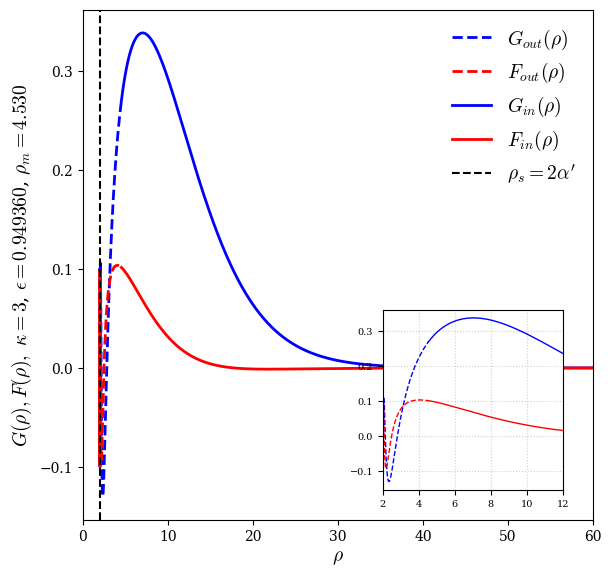

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson
from scipy.optimize import root_scalar
from scipy.special import lambertw
import pandas as pd

# --- Physical Parameters ---
alpha_prime = 1.0   # M / lambda_c
kappa = 3          # spin-orbit coupling
#kappas = [ -5, -4, -2, -1, 1, 2, 4, 5]
save_dir = './'

# --- Turtoise Coordinate Mapping ---
def transf_rho(rho_star):
    """
    Exactly converts Tortoise coordinate (rho*) to physical radial coordinate (rho)
    using the analytical Lambert W function.
    """
    # z = exp((rho* - 2a) / 2a)
    z = np.exp((rho_star - 2 * alpha_prime) / (2 * alpha_prime))
    # rho = 2a * [1 + W(z)]
    # We take the real part since we are in the strictly positive domain
    w = lambertw(z)
    return 2 * alpha_prime * (1 + np.real(w))

def transf_rho_star(rho):
    return rho + 2 * alpha_prime * np.log(rho / (2 * alpha_prime) - 1)

# --- Coupled Radial Dirac Equations ---
def dirac_tortoise_system(rho_star, y, epsilon):
    """
    y[0] = G, y[1] = F
    Derivatives are with respect to rho*
    """
    G, F = y
    rho = transf_rho(rho_star)
    f = 1 - 2 * alpha_prime / rho
    sqrt_f = np.sqrt(f)

    # The equations multiplied by f (d/drho* = f * d/drho)
    dG_drhostar = -sqrt_f * (kappa / rho) * G + (sqrt_f + epsilon) * F
    dF_drhostar =  sqrt_f * (kappa / rho) * F + (sqrt_f - epsilon) * G

    return [dG_drhostar, dF_drhostar]

# --- The Shooting Method Engine ---
def energy_mismatch(epsilon, return_wavefunction=False):
    # Integration Boundaries (Tortoise Coordinates)
    rho_min = 2 * alpha_prime + 1e-8  # Just outside the horizon
    rho_max = 300.0 # Spatial infinity approximation

    rho_star_min = transf_rho_star(rho_min) # Deep near the event horizon
    rho_star_max = transf_rho_star(rho_max)  # Spatial infinity
    rho_star_m = 5

    # 1. Asymptotic Initial Conditions at Horizon (rho* -> -infty)
    # G ~ sin(eps * rho*), F ~ cos(eps * rho*)
    G_out_init = np.sin(epsilon * rho_star_min)
    F_out_init = np.cos(epsilon * rho_star_min)

    # 2. Asymptotic Initial Conditions at Infinity (rho* -> +infty)
    # G ~ e^(-lambda * rho*), F = -sqrt((1-eps)/(1+eps)) * G
    G_in_init = 1 # np.exp(-np.sqrt(1-epsilon**2) * rho_star_max)
    # it isn't be computed to avoid underflow limit and assumed to be 1e-6
    F_in_init = -np.sqrt((1 - epsilon) / (1 + epsilon)) * G_in_init

    # Boundary Conditions
    psi_init_out = [1e-6 * G_out_init, 1e-6 * F_out_init] # at horizon
    psi_init_in  = [1e-6 * G_in_init, 1e-6 * F_in_init] # at infinity

    # Outward Integration
    psi_out = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_min, rho_star_m],
        y0=psi_init_out,
        args=(epsilon,),
        method='Radau', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Inward Integration
    psi_in = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_max, rho_star_m],
        y0=psi_init_in,
        args=(epsilon,),
        method='RK45', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Extract matching point values
    G_out, F_out = psi_out.y[:, -1]
    G_in, F_in   = psi_in.y[:, -1]
    scale_factor = F_out / F_in
    #scale_factor = G_out / G_in
    Delta = G_out-G_in*scale_factor

    if return_wavefunction:
        return psi_out, psi_in, scale_factor, rho_star_m
    return Delta


    # Bracket roughly where we expect the ground state (e.g., 0.95 to 0.999)
root_eps = root_scalar(
    energy_mismatch,
    bracket=[0.85, 0.999],
    method='brentq',
    xtol=1e-14,
    )

if root_eps.converged:
    true_eps = root_eps.root
    print(f"Converged energy eigenvalue, epsilon = {true_eps:.6f}")

    # Re-run to extract components
    psi_out, psi_in, scale_factor, rho_star_m = energy_mismatch(true_eps, return_wavefunction=True)

    # Generate dense grids for normalization and plotting
    rs_out_grid = np.linspace(psi_out.t[0], psi_out.t[-1], 40000)
    rs_in_grid = np.linspace(psi_in.t[-1], psi_in.t[0], 40000)

    Psi_out = psi_out.sol(rs_out_grid)
    Psi_in_scaled = psi_in.sol(rs_in_grid) * scale_factor

    rho_out = np.array([transf_rho(rs) for rs in rs_out_grid])
    rho_in = np.array([transf_rho(rs) for rs in rs_in_grid])

    # Normalization using Simpson's Rule
    density_out = Psi_out[0]**2 + Psi_out[1]**2
    density_in = Psi_in_scaled[0]**2 + Psi_in_scaled[1]**2

    total_norm = simpson(density_out, rho_out) + simpson(density_in, rho_in)
    normalization_factor = np.sqrt(total_norm) if total_norm > 0 else 1.0

    # Plotting
    fig = plt.figure(figsize=(6, 6))
    plt.plot(rho_out, Psi_out[0]/normalization_factor, 'b--', lw=2, label=r'$G_{out}(\rho)$')
    plt.plot(rho_out, Psi_out[1]/normalization_factor, 'r--', lw=2, label=r'$F_{out}(\rho)$')
    plt.plot(rho_in, Psi_in_scaled[0]/normalization_factor, 'b-', lw=2, label=r'$G_{in}(\rho)$')
    plt.plot(rho_in, Psi_in_scaled[1]/normalization_factor, 'r-', lw=2, label=r'$F_{in}(\rho)$')
    plt.axvline(2*alpha_prime, color='black', linestyle='--', label=r"$\rho_s = 2\alpha^{\prime}$")
    plt.xlabel(r"$\rho$", fontsize=14)
    plt.ylabel(rf"$G(\rho), F(\rho),$ $\kappa = {kappa}$, $\epsilon = {true_eps:.6f}$, $\rho_m={transf_rho(rho_star_m):.3f}$", fontsize=14)
    plt.xlim(0,60)
    #plt.ylim(-1.1, 1.1)
    plt.legend(loc='upper right', fontsize=14, frameon=False, shadow=False)
    #plt.grid(alpha=0.3)

    # --- Inset Zoomed Plot ---
    ax_inset = fig.add_axes([0.6, 0.15, 0.3, 0.3])

    ax_inset.plot(rho_out, Psi_out[0] / normalization_factor, 'b--', lw=1.0)
    ax_inset.plot(rho_out, Psi_out[1] / normalization_factor, 'r--', lw=1.0)
    ax_inset.plot(rho_in, Psi_in_scaled[0] / normalization_factor, 'b-', lw=1.0)
    ax_inset.plot(rho_in, Psi_in_scaled[1] / normalization_factor, 'r-', lw=1.0)

    zoom_rho_start = 2 * alpha_prime
    zoom_rho_end =  2 * alpha_prime + 10
    ax_inset.set_xlim(zoom_rho_start, zoom_rho_end)
    ax_inset.tick_params(axis='x', labelsize=7)
    ax_inset.tick_params(axis='y', labelsize=7)
    ax_inset.grid(True, linestyle=':', alpha=0.6)
    fig.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.95)
    filename = os.path.join(save_dir, f'Rwfc_turtoise_usingdG_epsilon={true_eps:.6f}_kappa={kappa}_rho_m={transf_rho(rho_star_m):.3f}.png')
    plt.savefig(filename, dpi=350, bbox_inches='tight')
    plt.show()
else:
    print("Failed to converge on an eigenvalue.")



#### Domain Koordinat *Tortoise*

Converged energy eigenvalue, epsilon = 0.977294


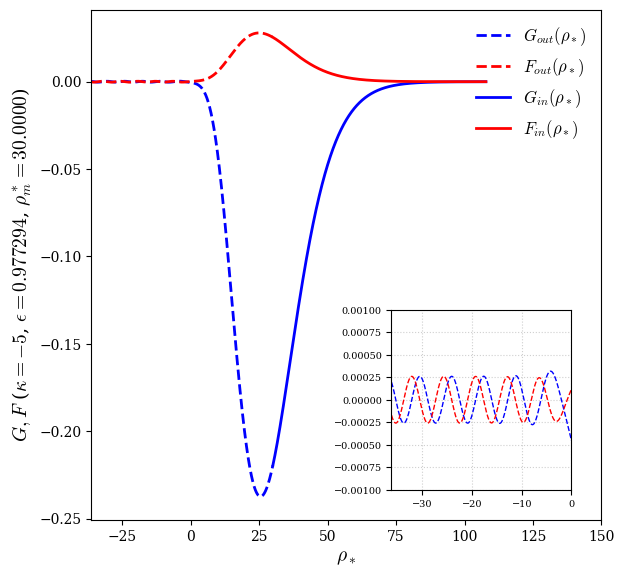

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson
from scipy.optimize import root_scalar
from scipy.special import lambertw
import pandas as pd

# --- Physical Parameters ---
alpha_prime = 1.0   # M / lambda_c
kappa = -5          # spin-orbit coupling
#kappas = [ -5, -4, -2, -1, 1, 2, 4, 5]
save_dir = './'

# --- Turtoise Coordinate Mapping ---
def transf_rho(rho_star):
    """
    Exactly converts Tortoise coordinate (rho*) to physical radial coordinate (rho)
    using the analytical Lambert W function.
    """
    # z = exp((rho* - 2a) / 2a)
    z = np.exp((rho_star - 2 * alpha_prime) / (2 * alpha_prime))
    # rho = 2a * [1 + W(z)]
    # We take the real part since we are in the strictly positive domain
    w = lambertw(z)
    return 2 * alpha_prime * (1 + np.real(w))

def transf_rho_star(rho):
    return rho + 2 * alpha_prime * np.log(rho / (2 * alpha_prime) - 1)

# --- Coupled Radial Dirac Equations ---
def dirac_tortoise_system(rho_star, y, epsilon):
    """
    y[0] = G, y[1] = F
    Derivatives are with respect to rho*
    """
    G, F = y
    rho = transf_rho(rho_star)
    f = 1 - 2 * alpha_prime / rho
    sqrt_f = np.sqrt(f)

    # The equations multiplied by f (d/drho* = f * d/drho)
    dG_drhostar = -sqrt_f * (kappa / rho) * G + (sqrt_f + epsilon) * F
    dF_drhostar =  sqrt_f * (kappa / rho) * F + (sqrt_f - epsilon) * G

    return [dG_drhostar, dF_drhostar]

# --- The Shooting Method Engine ---
def energy_mismatch(epsilon, return_wavefunction=False):
    # Integration Boundaries (Tortoise Coordinates)
    rho_min = 2 * alpha_prime + 1e-8  # Just outside the horizon
    rho_max = 100.0 # Spatial infinity approximation

    rho_star_min = transf_rho_star(rho_min) # Deep near the event horizon
    rho_star_max = transf_rho_star(rho_max)  # Spatial infinity
    rho_star_m = 30

    # 1. Asymptotic Initial Conditions at Horizon (rho* -> -infty)
    # G ~ sin(eps * rho*), F ~ cos(eps * rho*)
    G_out_init = np.sin(epsilon * rho_star_min)
    F_out_init = np.cos(epsilon * rho_star_min)

    # 2. Asymptotic Initial Conditions at Infinity (rho* -> +infty)
    # G ~ e^(-lambda * rho*), F = -sqrt((1-eps)/(1+eps)) * G
    G_in_init = 1 # np.exp(-np.sqrt(1-epsilon**2) * rho_star_max)
    # it isn't be computed to avoid underflow limit and assumed to be 1e-6
    F_in_init = -np.sqrt((1 - epsilon) / (1 + epsilon)) * G_in_init

    # Boundary Conditions
    psi_init_out = [1e-6 * G_out_init, 1e-6 * F_out_init] # at horizon
    psi_init_in  = [1e-6 * G_in_init, 1e-6 * F_in_init] # at infinity

    # Outward Integration
    psi_out = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_min, rho_star_m],
        y0=psi_init_out,
        args=(epsilon,),
        method='Radau', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Inward Integration
    psi_in = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_max, rho_star_m],
        y0=psi_init_in,
        args=(epsilon,),
        method='RK45', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Extract matching point values
    G_out, F_out = psi_out.y[:, -1]
    G_in, F_in   = psi_in.y[:, -1]
    #scale_factor = F_out / F_in
    scale_factor = G_out / G_in
    Delta = F_out-F_in*scale_factor

    if return_wavefunction:
        return psi_out, psi_in, scale_factor, rho_star_m
    return Delta


    # Bracket roughly where we expect the ground state (e.g., 0.95 to 0.999)
root_eps = root_scalar(
    energy_mismatch,
    bracket=[0.95, 0.99],
    method='brentq',
    xtol=1e-14,
    )

if root_eps.converged:
    true_eps = root_eps.root
    print(f"Converged energy eigenvalue, epsilon = {true_eps:.6f}")

    # Re-run to extract components
    psi_out, psi_in, scale_factor, rho_star_m = energy_mismatch(true_eps, return_wavefunction=True)

    # Generate dense grids for normalization and plotting
    rs_out_grid = np.linspace(psi_out.t[0], psi_out.t[-1], 40000)
    rs_in_grid = np.linspace(psi_in.t[-1], psi_in.t[0], 40000)

    Psi_out = psi_out.sol(rs_out_grid)
    Psi_in_scaled = psi_in.sol(rs_in_grid) * scale_factor

    rho_out = np.array([transf_rho(rs) for rs in rs_out_grid])
    rho_in = np.array([transf_rho(rs) for rs in rs_in_grid])

    # Normalization using Simpson's Rule (KEEP THIS AS physical rho)
    density_out = Psi_out[0]**2 + Psi_out[1]**2
    density_in = Psi_in_scaled[0]**2 + Psi_in_scaled[1]**2

    total_norm = simpson(density_out, rho_out) + simpson(density_in, rho_in)
    normalization_factor = np.sqrt(total_norm) if total_norm > 0 else 1.0

    # ==========================================
    # --- UPDATED PLOTTING (TORTOISE COORDS) ---
    # ==========================================
    fig = plt.figure(figsize=(6, 6))

    # Plot against rs_out_grid and rs_in_grid instead of rho_out and rho_in
    plt.plot(rs_out_grid, Psi_out[0]/normalization_factor, 'b--', lw=2, label=r'$G_{out}(\rho_*)$')
    plt.plot(rs_out_grid, Psi_out[1]/normalization_factor, 'r--', lw=2, label=r'$F_{out}(\rho_*)$')
    plt.plot(rs_in_grid, Psi_in_scaled[0]/normalization_factor, 'b-', lw=2, label=r'$G_{in}(\rho_*)$')
    plt.plot(rs_in_grid, Psi_in_scaled[1]/normalization_factor, 'r-', lw=2, label=r'$F_{in}(\rho_*)$')

    # Note: The event horizon is now at rho_* -> -infinity.
    # We will draw a line at the starting integration point to represent the deep horizon limit
    #plt.axvline(rs_out_grid[0], color='black', linestyle='--', label=r" Horizon Peristiwa ($\rho_* \to -\infty$)")

    plt.xlabel(r"$\rho_*$", fontsize=14)
    plt.ylabel(rf"$G, F$ ($\kappa = {kappa}$, $\epsilon = {true_eps:.6f}$, $\rho^*_m = {rho_star_m:.4f}$)", fontsize=14)

    # Adjust x-limits to show the deep horizon behavior (negative rho_*)
    plt.xlim(rs_out_grid[0], 150)
    plt.legend(loc='upper right', fontsize=12, frameon=False, shadow=False)

    # --- Inset Zoomed Plot (Near Event Horizon) ---
    ax_inset = fig.add_axes([0.6, 0.15, 0.3, 0.3])

    ax_inset.plot(rs_out_grid, Psi_out[0] / normalization_factor, 'b--', lw=1.0)
    ax_inset.plot(rs_out_grid, Psi_out[1] / normalization_factor, 'r--', lw=1.0)
    ax_inset.plot(rs_in_grid, Psi_in_scaled[0] / normalization_factor, 'b-', lw=1.0)
    ax_inset.plot(rs_in_grid, Psi_in_scaled[1] / normalization_factor, 'r-', lw=1.0)

    # Zoom in on the negative tortoise coordinates where the horizon barrier is
    zoom_rhostar_start = rs_out_grid[0]
    zoom_rhostar_end = 0  # Zoom up to rho_* = 0
    ax_inset.set_ylim(-0.001,0.001)
    ax_inset.set_xlim(zoom_rhostar_start, zoom_rhostar_end)
    ax_inset.tick_params(axis='x', labelsize=7)
    ax_inset.tick_params(axis='y', labelsize=7)
    ax_inset.grid(True, linestyle=':', alpha=0.6)

    fig.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.95)

    filename = os.path.join(save_dir, f'Rwfc_Turtoise_no-W-func_del-F_eps={true_eps:.6f}_kappa={kappa}.png')
    plt.savefig(filename, dpi=350, bbox_inches='tight')
    plt.show()
else:
    print("Failed to converge on an eigenvalue.")

## Nilai Eigen Kompleks (*Decay Rate*) dengan Domain Komputasional Koordinat Tortoise
Menggunakan *guessing* nilai eigen kompleks untuk mendapatkan energi nilai eigen yang imajiner yang menunjukkan laju peluruhan keadaan terikat. Guessing nilai eigen kompleks ini didasarkan pada beberapa penelitian menyebutkan dan bahwa energi bagian imajiner energi kompleks tersebut merupakan laju peluruhan yang mengukur seberapa cepat partikel tertelan oleh horizon, kita asumsikan nilai eigennya adalah $\epsilon_\text{com}=E_R+\mathrm i\Gamma$. *guessing* fungsi eigen yang digunakan adalah:

 * $ \rho^* \rightarrow + \infty$ (di ketakhinggan)
 * $G \approx 1+0\mathrm i$
 * $F \approx \sqrt{\frac{1-\epsilon_\text{com}}{1+\epsilon_\text{com}}}G$
 * $ \rho^* \rightarrow - \infty$ (di horizon)
 * $G \approx 1+0\mathrm i$
 * $F \approx 0-\mathrm i.$

 Pada bagian ini, kita sepenuhnya bekerja dalam domain komputasional koordinat tortoise.  

### Domain Koordinat Radial (Invers melalui Fungsi Lambert-W)
$\rho^*→\rho = 2\alpha'+2\alpha'W\left(\exp\left[\frac{\rho^*-2\alpha'}{2\alpha'}\right]\right)$

Searching for complex quasi-bound state eigenvalue...

Converged Complex Eigenvalue: 0.99192336-0.00353032j
Real Energy (E_R): 0.99192336
Decay Rate (Gamma): 3.530e-03



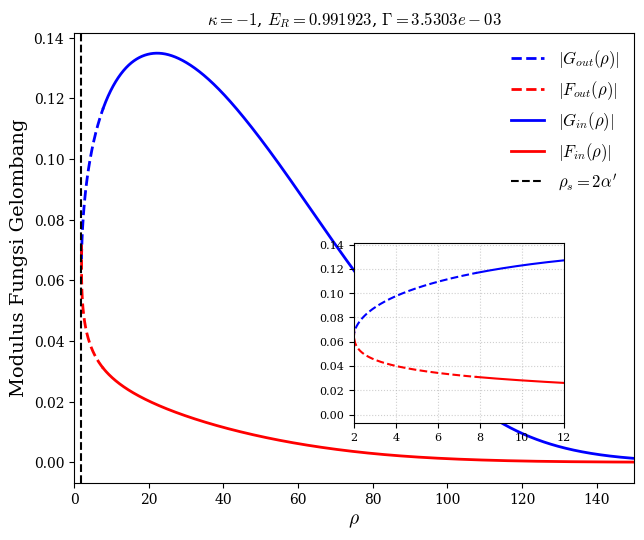

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson
from scipy.optimize import root
from scipy.special import lambertw

# --- Physical Parameters ---
alpha_prime = 1.0   # M / lambda_c
kappa = -1          # spin-orbit coupling
save_dir = './'    # Changed to current dir for testing, update to your Google Drive path

# --- Turtoise Coordinate Mapping ---
def transf_rho(rho_star):
    z = np.exp((rho_star - 2 * alpha_prime) / (2 * alpha_prime))
    w = lambertw(z)
    return 2 * alpha_prime * (1 + np.real(w))

def transf_rho_star(rho):
    return rho + 2 * alpha_prime * np.log(rho / (2 * alpha_prime) - 1)

# --- SPLIT Coupled Radial Dirac Equations ---
def dirac_tortoise_system_split(rho_star, y_split, epsilon):
    """
    Takes 4 real variables, recombines them into complex G and F,
    evaluates the derivatives, and returns 4 real derivatives.
    y_split = [G_real, F_real, G_imag, F_imag]
    """
    G = y_split[0] + 1j * y_split[2]
    F = y_split[1] + 1j * y_split[3]

    rho = transf_rho(rho_star)
    f = 1 - 2 * alpha_prime / rho
    sqrt_f = np.sqrt(f)

    dG = -sqrt_f * (kappa / rho) * G + (sqrt_f + epsilon) * F
    dF =  sqrt_f * (kappa / rho) * F + (sqrt_f - epsilon) * G

    # Return as 4 flat Real numbers
    return [np.real(dG), np.real(dF), np.imag(dG), np.imag(dF)]

# --- The Complex Shooting Method Engine ---
def complex_energy_mismatch(eps_complex, return_wavefunction=False):
    rho_min = 2 * alpha_prime + 1e-8
    rho_max = 300.0
    rho_star_min = transf_rho_star(rho_min)
    rho_star_max = transf_rho_star(rho_max)
    rho_star_m = 10.0

    # 1. PURELY INGOING Wave at the Horizon (Complex)
    G_out_init = 1.0 + 0.0j
    F_out_init = 0.0 - 1.0j

    # 2. Exponential Decay at Infinity (Complex)
    G_in_init = 1.0 + 0.0j
    F_in_init = -np.sqrt((1 - eps_complex) / (1 + eps_complex)) * G_in_init

    # Original Complex Arrays
    psi_init_out = [1e-6 * G_out_init, 1e-6 * F_out_init]
    psi_init_in  = [1e-6 * G_in_init, 1e-6 * F_in_init]

    # Split into Real and Imaginary for the solvers [G_R, F_R, G_I, F_I]
    y0_out_split = [np.real(psi_init_out[0]), np.real(psi_init_out[1]),
                    np.imag(psi_init_out[0]), np.imag(psi_init_out[1])]

    y0_in_split  = [np.real(psi_init_in[0]), np.real(psi_init_in[1]),
                    np.imag(psi_init_in[0]), np.imag(psi_init_in[1])]

    # Outward Integration (Now using Real numbers so Radau works perfectly)
    psi_out = solve_ivp(
        dirac_tortoise_system_split,
        t_span=[rho_star_min, rho_star_m],
        y0=y0_out_split,
        args=(eps_complex,),
        method='Radau', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Inward Integration
    psi_in = solve_ivp(
        dirac_tortoise_system_split,
        t_span=[rho_star_max, rho_star_m],
        y0=y0_in_split,
        args=(eps_complex,),
        method='RK45', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Reconstruct complex values at the matching point
    G_out = psi_out.y[0, -1] + 1j * psi_out.y[2, -1]
    F_out = psi_out.y[1, -1] + 1j * psi_out.y[3, -1]

    G_in = psi_in.y[0, -1] + 1j * psi_in.y[2, -1]
    F_in = psi_in.y[1, -1] + 1j * psi_in.y[3, -1]

    # Use the smooth Wronskian Determinant for the root finder
    Delta = G_out * F_in - G_in * F_out

    if return_wavefunction:
        scale_factor = F_out / F_in
        return psi_out, psi_in, scale_factor, rho_star_m
    return Delta

def mismatch_wrapper(eps_arr):
    eps_complex = eps_arr[0] + 1j * eps_arr[1]
    Delta = complex_energy_mismatch(eps_complex)
    return [Delta.real, Delta.imag]

# ----------------------------------------------------
# PUSH TO SOLVER
# ----------------------------------------------------
initial_guess = [0.89, -1e-4]

print("Searching for complex quasi-bound state eigenvalue...")
root_eps = root(
    mismatch_wrapper,
    x0=initial_guess,
    method='hybr',
    tol=1e-10
)

if root_eps.success:
    true_eps_complex = root_eps.x[0] + 1j * root_eps.x[1]

    real_energy = np.real(true_eps_complex)
    decay_rate = -np.imag(true_eps_complex)

    print(f"\nConverged Complex Eigenvalue: {true_eps_complex:.8f}")
    print(f"Real Energy (E_R): {real_energy:.8f}")
    print(f"Decay Rate (Gamma): {decay_rate:.3e}\n")

    # Re-run to extract components
    psi_out, psi_in, scale_factor, rho_star_m = complex_energy_mismatch(true_eps_complex, return_wavefunction=True)

    # Generate dense grids
    rs_out_grid = np.linspace(psi_out.t[0], psi_out.t[-1], 20000)
    rs_in_grid = np.linspace(psi_in.t[-1], psi_in.t[0], 20000)

    # Evaluate dense output and reconstruct complex waves
    sol_out = psi_out.sol(rs_out_grid)
    Psi_out_complex = np.array([sol_out[0] + 1j*sol_out[2], sol_out[1] + 1j*sol_out[3]])

    sol_in = psi_in.sol(rs_in_grid)
    Psi_in_complex_scaled = np.array([sol_in[0] + 1j*sol_in[2], sol_in[1] + 1j*sol_in[3]]) * scale_factor

    rho_out = np.array([transf_rho(rs) for rs in rs_out_grid])
    rho_in = np.array([transf_rho(rs) for rs in rs_in_grid])

    # Normalization using Modulus Squared (|G|^2 + |F|^2)
    density_out = np.abs(Psi_out_complex[0])**2 + np.abs(Psi_out_complex[1])**2
    density_in = np.abs(Psi_in_complex_scaled[0])**2 + np.abs(Psi_in_complex_scaled[1])**2

    total_norm = simpson(density_out, x=rho_out) + simpson(density_in, x=rho_in)
    normalization_factor = np.sqrt(total_norm) if total_norm > 0 else 1.0

    # Extract Absolute Magnitudes for plotting
    G_out_plot = np.abs(Psi_out_complex[0]) / normalization_factor
    F_out_plot = np.abs(Psi_out_complex[1]) / normalization_factor
    G_in_plot = np.abs(Psi_in_complex_scaled[0]) / normalization_factor
    F_in_plot = np.abs(Psi_in_complex_scaled[1]) / normalization_factor

    # --- Plotting ---
    fig = plt.figure(figsize=(7, 6))
    plt.plot(rho_out, G_out_plot, 'b--', lw=2, label=r'$|G_{out}(\rho)|$')
    plt.plot(rho_out, F_out_plot, 'r--', lw=2, label=r'$|F_{out}(\rho)|$')
    plt.plot(rho_in, G_in_plot, 'b-', lw=2, label=r'$|G_{in}(\rho)|$')
    plt.plot(rho_in, F_in_plot, 'r-', lw=2, label=r'$|F_{in}(\rho)|$')

    plt.axvline(2*alpha_prime, color='black', linestyle='--', label=r"$\rho_s = 2\alpha^{\prime}$")
    plt.xlabel(r"$\rho$", fontsize=14)
    plt.ylabel(rf"Modulus Fungsi Gelombang", fontsize=14)
    plt.title(rf"$\kappa = {kappa}$, $E_R = {real_energy:.6f}$, $\Gamma = {decay_rate:.4e}$", fontsize=12)
    plt.xlim(0, 150)
    plt.legend(loc='upper right', fontsize=12, frameon=False)

    # --- Inset Zoomed Plot ---
    ax_inset = fig.add_axes([0.55, 0.25, 0.3, 0.3])
    ax_inset.plot(rho_out, G_out_plot, 'b--', lw=1.5)
    ax_inset.plot(rho_out, F_out_plot, 'r--', lw=1.5)
    ax_inset.plot(rho_in, G_in_plot, 'b-', lw=1.5)
    ax_inset.plot(rho_in, F_in_plot, 'r-', lw=1.5)

    ax_inset.set_xlim(2 * alpha_prime, 2 * alpha_prime + 10)
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, linestyle=':', alpha=0.6)

    fig.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.9)
    plt.savefig(os.path.join(save_dir, f'Complex_wfc_kappa={kappa}.png'), dpi=350, bbox_inches='tight')
    plt.show()

else:
    print("Complex root finder failed to converge.")
    print("HINT: Change `initial_guess` to match the EXACT Real Energy you previously found for this Kappa.")

### Domain Koordinat *Tortoise*

Searching for complex quasi-bound state eigenvalue...

Converged Complex Eigenvalue: 0.99192336-0.00353032j
Real Energy (E_R): 0.99192336
Decay Rate (Gamma): 3.530e-03



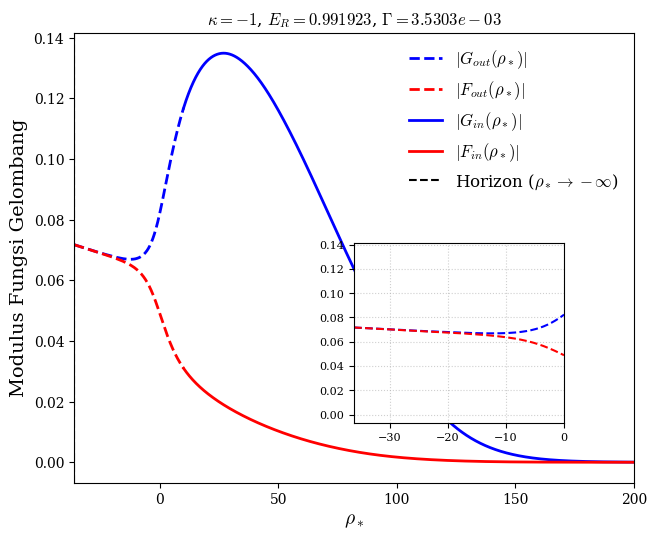

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson
from scipy.optimize import root
from scipy.special import lambertw

# --- Physical Parameters ---
alpha_prime = 1.0   # M / lambda_c
kappa = -1          # spin-orbit coupling
save_dir = './'    # Changed to current dir for testing, update to your Google Drive path

# --- Turtoise Coordinate Mapping ---
def transf_rho(rho_star):
    z = np.exp((rho_star - 2 * alpha_prime) / (2 * alpha_prime))
    w = lambertw(z)
    return 2 * alpha_prime * (1 + np.real(w))

def transf_rho_star(rho):
    return rho + 2 * alpha_prime * np.log(rho / (2 * alpha_prime) - 1)

# --- SPLIT Coupled Radial Dirac Equations ---
def dirac_tortoise_system_split(rho_star, y_split, epsilon):
    """
    Takes 4 real variables, recombines them into complex G and F,
    evaluates the derivatives, and returns 4 real derivatives.
    y_split = [G_real, F_real, G_imag, F_imag]
    """
    G = y_split[0] + 1j * y_split[2]
    F = y_split[1] + 1j * y_split[3]

    rho = transf_rho(rho_star)
    f = 1 - 2 * alpha_prime / rho
    sqrt_f = np.sqrt(f)

    dG = -sqrt_f * (kappa / rho) * G + (sqrt_f + epsilon) * F
    dF =  sqrt_f * (kappa / rho) * F + (sqrt_f - epsilon) * G

    # Return as 4 flat Real numbers
    return [np.real(dG), np.real(dF), np.imag(dG), np.imag(dF)]

# --- The Complex Shooting Method Engine ---
def complex_energy_mismatch(eps_complex, return_wavefunction=False):
    rho_min = 2 * alpha_prime + 1e-8
    rho_max = 300.0
    rho_star_min = transf_rho_star(rho_min)
    rho_star_max = transf_rho_star(rho_max)
    rho_star_m = 10.0

    # 1. PURELY INGOING Wave at the Horizon (Complex)
    G_out_init = 1.0 + 0.0j
    F_out_init = 0.0 - 1.0j

    # 2. Exponential Decay at Infinity (Complex)
    G_in_init = 1.0 + 0.0j
    F_in_init = -np.sqrt((1 - eps_complex) / (1 + eps_complex)) * G_in_init

    # Original Complex Arrays
    psi_init_out = [1e-6 * G_out_init, 1e-6 * F_out_init]
    psi_init_in  = [1e-6 * G_in_init, 1e-6 * F_in_init]

    # Split into Real and Imaginary for the solvers [G_R, F_R, G_I, F_I]
    y0_out_split = [np.real(psi_init_out[0]), np.real(psi_init_out[1]),
                    np.imag(psi_init_out[0]), np.imag(psi_init_out[1])]

    y0_in_split  = [np.real(psi_init_in[0]), np.real(psi_init_in[1]),
                    np.imag(psi_init_in[0]), np.imag(psi_init_in[1])]

    # Outward Integration (Now using Real numbers so Radau works perfectly)
    psi_out = solve_ivp(
        dirac_tortoise_system_split,
        t_span=[rho_star_min, rho_star_m],
        y0=y0_out_split,
        args=(eps_complex,),
        method='Radau', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Inward Integration
    psi_in = solve_ivp(
        dirac_tortoise_system_split,
        t_span=[rho_star_max, rho_star_m],
        y0=y0_in_split,
        args=(eps_complex,),
        method='RK45', dense_output=True, rtol=1e-8, atol=1e-10
    )

    # Reconstruct complex values at the matching point
    G_out = psi_out.y[0, -1] + 1j * psi_out.y[2, -1]
    F_out = psi_out.y[1, -1] + 1j * psi_out.y[3, -1]

    G_in = psi_in.y[0, -1] + 1j * psi_in.y[2, -1]
    F_in = psi_in.y[1, -1] + 1j * psi_in.y[3, -1]

    # Use the smooth Wronskian Determinant for the root finder
    Delta = G_out * F_in - G_in * F_out

    if return_wavefunction:
        scale_factor = F_out / F_in
        return psi_out, psi_in, scale_factor, rho_star_m
    return Delta

def mismatch_wrapper(eps_arr):
    eps_complex = eps_arr[0] + 1j * eps_arr[1]
    Delta = complex_energy_mismatch(eps_complex)
    return [Delta.real, Delta.imag]

# ----------------------------------------------------
# PUSH TO SOLVER
# ----------------------------------------------------
# NOTE: Replace the 0.96 with whatever real Energy you found for kappa=3 in your earlier code
initial_guess = [0.89, -1e-4]

print("Searching for complex quasi-bound state eigenvalue...")
root_eps = root(
    mismatch_wrapper,
    x0=initial_guess,
    method='hybr',
    tol=1e-10
)

if root_eps.success:
    true_eps_complex = root_eps.x[0] + 1j * root_eps.x[1]

    real_energy = np.real(true_eps_complex)
    decay_rate = -np.imag(true_eps_complex)

    print(f"\nConverged Complex Eigenvalue: {true_eps_complex:.8f}")
    print(f"Real Energy (E_R): {real_energy:.8f}")
    print(f"Decay Rate (Gamma): {decay_rate:.3e}\n")

    # Re-run to extract components
    psi_out, psi_in, scale_factor, rho_star_m = complex_energy_mismatch(true_eps_complex, return_wavefunction=True)

    # Generate dense grids
    rs_out_grid = np.linspace(psi_out.t[0], psi_out.t[-1], 20000)
    rs_in_grid = np.linspace(psi_in.t[-1], psi_in.t[0], 20000)

    # Evaluate dense output and reconstruct complex waves
    sol_out = psi_out.sol(rs_out_grid)
    Psi_out_complex = np.array([sol_out[0] + 1j*sol_out[2], sol_out[1] + 1j*sol_out[3]])

    sol_in = psi_in.sol(rs_in_grid)
    Psi_in_complex_scaled = np.array([sol_in[0] + 1j*sol_in[2], sol_in[1] + 1j*sol_in[3]]) * scale_factor

    rho_out = np.array([transf_rho(rs) for rs in rs_out_grid])
    rho_in = np.array([transf_rho(rs) for rs in rs_in_grid])

    # Normalization using Modulus Squared (|G|^2 + |F|^2)
    density_out = np.abs(Psi_out_complex[0])**2 + np.abs(Psi_out_complex[1])**2
    density_in = np.abs(Psi_in_complex_scaled[0])**2 + np.abs(Psi_in_complex_scaled[1])**2

    total_norm = simpson(density_out, x=rho_out) + simpson(density_in, x=rho_in)
    normalization_factor = np.sqrt(total_norm) if total_norm > 0 else 1.0

    # Extract Absolute Magnitudes for plotting
    G_out_plot = np.abs(Psi_out_complex[0]) / normalization_factor
    F_out_plot = np.abs(Psi_out_complex[1]) / normalization_factor
    G_in_plot = np.abs(Psi_in_complex_scaled[0]) / normalization_factor
    F_in_plot = np.abs(Psi_in_complex_scaled[1]) / normalization_factor


    # --- Plotting in Tortoise Coordinates ---
    fig = plt.figure(figsize=(7, 6))

    # Swap rho_out and rho_in for rs_out_grid and rs_in_grid
    plt.plot(rs_out_grid, G_out_plot, 'b--', lw=2, label=r'$|G_{out}(\rho_*)|$')
    plt.plot(rs_out_grid, F_out_plot, 'r--', lw=2, label=r'$|F_{out}(\rho_*)|$')
    plt.plot(rs_in_grid, G_in_plot, 'b-', lw=2, label=r'$|G_{in}(\rho_*)|$')
    plt.plot(rs_in_grid, F_in_plot, 'r-', lw=2, label=r'$|F_{in}(\rho_*)|$')

    # The horizon in tortoise coordinates stretches to -infinity.
    # We place the marker at the very beginning of our integration grid.
    plt.axvline(rs_out_grid[0], color='black', linestyle='--', label=r"Horizon ($\rho_* \to -\infty$)")

    plt.xlabel(r"$\rho_*$", fontsize=14)
    plt.ylabel(rf"Modulus Fungsi Gelombang", fontsize=14)
    plt.title(rf"$\kappa = {kappa}$, $E_R = {real_energy:.6f}$, $\Gamma = {decay_rate:.4e}$", fontsize=12)

    # Allow the plot to stretch deep into negative numbers to see the horizon
    plt.xlim(rs_out_grid[0], 200)
    plt.legend(loc='upper right', fontsize=12, frameon=False)

    # --- Inset Zoomed Plot (Focused on the Horizon) ---
    ax_inset = fig.add_axes([0.55, 0.25, 0.3, 0.3])
    ax_inset.plot(rs_out_grid, G_out_plot, 'b--', lw=1.5)
    ax_inset.plot(rs_out_grid, F_out_plot, 'r--', lw=1.5)
    ax_inset.plot(rs_in_grid, G_in_plot, 'b-', lw=1.5)
    ax_inset.plot(rs_in_grid, F_in_plot, 'r-', lw=1.5)

    # Zoom exclusively into the deep throat of the black hole
    ax_inset.set_xlim(rs_out_grid[0], 0)
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, linestyle=':', alpha=0.6)

    fig.subplots_adjust(left=0.15, bottom=0.15, right=0.95, top=0.9)
    plt.savefig(os.path.join(save_dir, f'Complex_wfc_Tortoise_kappa={kappa}.png'), dpi=350, bbox_inches='tight')
    plt.show()

else:
    print("Complex root finder failed to converge.")
    print("HINT: Change `initial_guess` to match the EXACT Real Energy you previously found for this Kappa.")

# Nilai Eigen Energi Persamaan Dirac dalam Medan Gravitasi Interior Schwarzschild yang Diperluas

## $\kappa=\pm1,\pm2$

Initiating Continuation Sweep for r_0 / r_s ...
r0/rs = 5.000 | Energy = 0.93210
r0/rs = 4.898 | Energy = 0.93080
r0/rs = 4.795 | Energy = 0.92945
r0/rs = 4.693 | Energy = 0.92804
r0/rs = 4.591 | Energy = 0.92656
r0/rs = 4.488 | Energy = 0.92502
r0/rs = 4.386 | Energy = 0.92340
r0/rs = 4.284 | Energy = 0.92171
r0/rs = 4.182 | Energy = 0.91994
r0/rs = 4.079 | Energy = 0.91807
r0/rs = 3.977 | Energy = 0.91611
r0/rs = 3.875 | Energy = 0.91404
r0/rs = 3.772 | Energy = 0.91185
r0/rs = 3.670 | Energy = 0.90954
r0/rs = 3.568 | Energy = 0.90709
r0/rs = 3.465 | Energy = 0.90449
r0/rs = 3.363 | Energy = 0.90172
r0/rs = 3.261 | Energy = 0.89877
r0/rs = 3.158 | Energy = 0.89561
r0/rs = 3.056 | Energy = 0.89223
r0/rs = 2.954 | Energy = 0.88858
r0/rs = 2.852 | Energy = 0.88465
r0/rs = 2.749 | Energy = 0.88039
r0/rs = 2.647 | Energy = 0.87575
r0/rs = 2.545 | Energy = 0.87068
r0/rs = 2.442 | Energy = 0.86511
r0/rs = 2.340 | Energy = 0.85896
r0/rs = 2.238 | Energy = 0.85211
r0/rs = 2.135 | Energy = 0.8

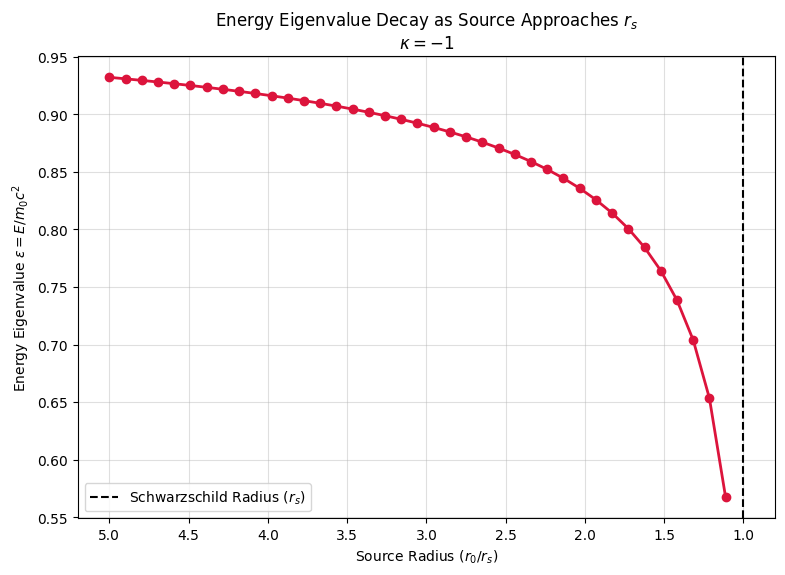

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.special import lambertw

# --- Physical Parameters ---
alpha_prime = 1.0
kappa = -1
r_s = 2 * alpha_prime # Schwarzschild radius

# --- Coordinate Mapping ---
def get_rho(rho_star):
    z = np.exp((rho_star - 2 * alpha_prime) / (2 * alpha_prime))
    w = lambertw(z)
    return 2 * alpha_prime * (1 + np.real(w))

def get_rho_star(rho):
    return rho + 2 * alpha_prime * np.log(rho / (2 * alpha_prime) - 1)

# --- The ODE System ---
def dirac_tortoise_system(rho_star, y, epsilon):
    G, F = y
    rho = get_rho(rho_star)
    f = 1 - 2 * alpha_prime / rho
    sqrt_f = np.sqrt(f)

    dG = -sqrt_f * (kappa / rho) * G + (sqrt_f + epsilon) * F
    dF =  sqrt_f * (kappa / rho) * F + (sqrt_f - epsilon) * G
    return [dG, dF]

# --- Wronskian Mismatch Engine ---
def compute_mismatch(epsilon, rho_surface, return_wavefunction=False):
    rho_star_min = get_rho_star(rho_surface)
    rho_star_max = 150.0
    rho_star_match = rho_star_min + 10.0 # Match slightly outside the star

    # 1. Inner Boundary at the Star's Surface (Hard wall approximation)
    G_out_init = 1e-6
    F_out_init = 0.0

    # 2. Asymptotic Initial Conditions at Infinity
    G_in_init = 1e-6
    F_in_init = -np.sqrt((1 - epsilon) / (1 + epsilon)) * G_in_init

    # Outward Integration (from surface to matching point)
    sol_out = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_min, rho_star_match],
        y0=[G_out_init, F_out_init],
        args=(epsilon,),
        method='RK45', rtol=1e-8, atol=1e-10
    )

    # Inward Integration (from infinity to matching point)
    sol_in = solve_ivp(
        dirac_tortoise_system,
        t_span=[rho_star_max, rho_star_match],
        y0=[G_in_init, F_in_init],
        args=(epsilon,),
        method='RK45', rtol=1e-8, atol=1e-10
    )

    G_out, F_out = sol_out.y[:, -1]
    G_in, F_in   = sol_in.y[:, -1]

    # Wronskian determinant (Zero when solutions match)
    mismatch = G_out * F_in - F_out * G_in

    if return_wavefunction:
        return sol_out, sol_in, G_out / G_in # Return scale factor for plotting
    return mismatch

# --- Dynamic Bracket Finder ---
def find_bracket(rho_surface, eps_start=0.85, eps_end=0.999, steps=100):
    """Scans for a sign change in the mismatch function to guarantee convergence."""
    eps_vals = np.linspace(eps_start, eps_end, steps)
    mismatches = [compute_mismatch(e, rho_surface) for e in eps_vals]

    for i in range(len(eps_vals) - 1):
        if mismatches[i] * mismatches[i+1] < 0:
            return [eps_vals[i], eps_vals[i+1]]
    return None

# --- Continuation Method (Parameter Sweep) ---
print("Initiating Continuation Sweep for r_0 / r_s ...")

# Create an array of star radii, compressing from 5*r_s down to 1.01*r_s
r0_array = np.linspace(5.0 * r_s, 1.01 * r_s, 40)
r0_over_rs_vals = []
energy_vals = []

# Dynamic search bounds (adjusted as we slide down the curve)
search_max = 0.999
search_min = 0.850

for r0 in r0_array:
    bracket = find_bracket(r0, search_min, search_max)

    if bracket:
        result = root_scalar(compute_mismatch, args=(r0,), bracket=bracket, method='brentq')
        if result.converged:
            E_exact = result.root
            r0_over_rs_vals.append(r0 / r_s)
            energy_vals.append(E_exact)
            print(f"r0/rs = {r0/r_s:.3f} | Energy = {E_exact:.5f}")

            # Update bounds to slide down the curve efficiently
            search_max = min(0.999, E_exact + 0.02)
            search_min = max(0.0, E_exact - 0.10)
        else:
            print(f"Failed to converge at r0/rs = {r0/r_s:.3f}")
    else:
        print(f"No bracket found for r0/rs = {r0/r_s:.3f}. The energy might have plunged below {search_min}.")

# --- Plotting Soffel's Figure 1 ---
plt.figure(figsize=(9, 6))
plt.plot(r0_over_rs_vals, energy_vals, marker='o', color='crimson', lw=2)
plt.axvline(1.0, color='black', linestyle='--', label="Schwarzschild Radius ($r_s$)")

plt.xlabel(r"Source Radius ($\rho_0 / \rho_s$)")
plt.ylabel(rf"$\epsilon = E / m_0 c^2,$ $\kappa={kappa}$")
plt.xlim(max(r0_over_rs_vals) + 0.2, 0.8) # Reverse X-axis to show compression
plt.legend()
plt.grid(alpha=0.4)
plt.show()

Initiating Continuation Sweep for rho_0 / rho_s ...

Processing κ = 1...
rho_0/rho_s = 3.5000 | Energy = 0.880848615892892
rho_0/rho_s = 3.3321 | Energy = 0.875415977687568
rho_0/rho_s = 3.1643 | Energy = 0.869287057562154
rho_0/rho_s = 2.9964 | Energy = 0.862297054348739
rho_0/rho_s = 2.8286 | Energy = 0.854222015222276
rho_0/rho_s = 2.6607 | Energy = 0.844749534384959
rho_0/rho_s = 2.4929 | Energy = 0.833430334669266
rho_0/rho_s = 2.3250 | Energy = 0.819594697396335
rho_0/rho_s = 2.1571 | Energy = 0.802200596707907
rho_0/rho_s = 1.9893 | Energy = 0.779540041595252
rho_0/rho_s = 1.8214 | Energy = 0.748625685022788
rho_0/rho_s = 1.6536 | Energy = 0.703773844769397
rho_0/rho_s = 1.4857 | Energy = 0.632825194673279
rho_0/rho_s = 1.3179 | Energy = 0.504253744989767
rho_0/rho_s = 1.1500 | Energy = 0.363379732786188
rho_0/rho_s = 1.1400 | Energy = 0.206996114428914
rho_0/rho_s = 1.1346 | Energy = 0.102577832827636
rho_0/rho_s = 1.1292 | Energy = 0.064098188860691
rho_0/rho_s = 1.1237 | Ener

,kappa=1,kappa=-1,kappa=2,kappa=-2
r0/rs,,,,
3.500000,0.880849,0.838637,0.922636,0.885785
3.332143,0.875416,0.830612,0.920001,0.881057
3.164286,0.869287,0.821621,0.917032,0.875776
2.996429,0.862297,0.811462,0.913640,0.869817
2.828571,0.854222,0.799868,0.909696,0.863007
2.660714,0.844750,0.786479,0.905012,0.855108
2.492857,0.833430,0.770796,0.899299,0.845770
2.325000,0.819595,0.752105,0.892090,0.834464
2.157143,0.802201,0.729341,0.882594,0.820345


Table saved to /content/drive/MyDrive/OTSAVLA/RESEARCH/dirac_energies_kappa12.csv


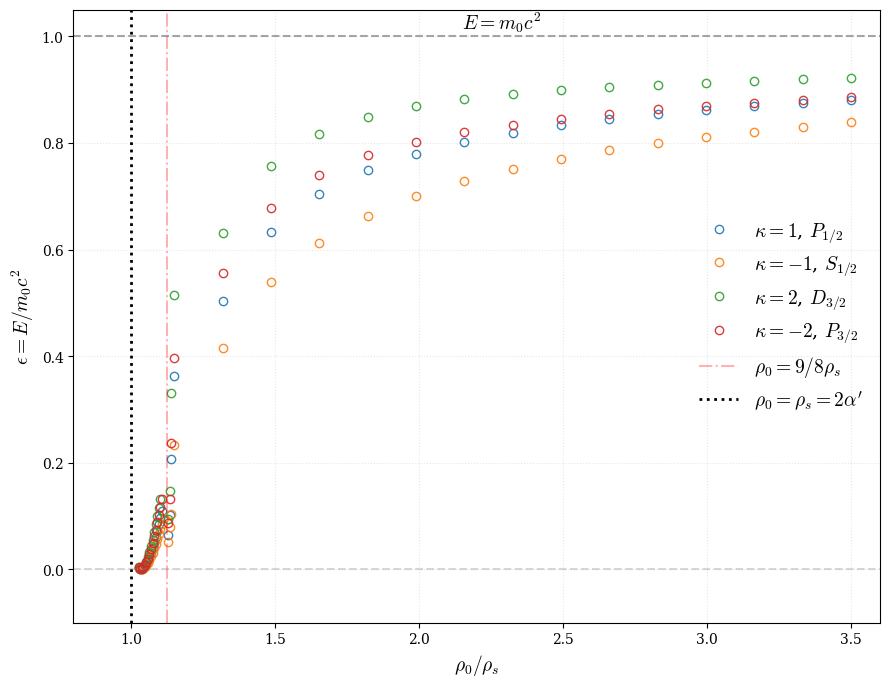

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from IPython.display import display
from scipy.interpolate import interp1d
import os # Import the os module for directory operations

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# --- Physical Parameters ---
alpha_prime = 1.0
#kappas = [1, -1, 2, -2, 4, -4, 5, -5, 10, -10]
kappas = [1,-1, 2, -2]
rho_s = 2 * alpha_prime

# --- The Generalized ODE System ---
def dirac_system(rho, psi, epsilon, rho_0, kappa):
    G, F = psi
    # INTERIOR SCHWARZSCHILD METRIC
    if rho <= rho_0:
        g11 = 1.0 / (1.0 - (rho_s * rho**2) / (rho_0**3))

        # --- to evaluate Buchdahl Limit ---
        if rho_0 <= (9.0 / 8.0) * rho_s:
            # Soffel's Analytical Continuation
            b = 1.0 / (rho_0**2 * (rho_0 / alpha_prime - 2.0))
            a = (1.0 - rho_s / rho_0) * np.exp(-b * rho_0**2)
            g00 = a * np.exp(b * rho**2)
        else:
            # Standard Constant-Density Interior
            term1 = (3/2) * np.sqrt(1.0 - rho_s / rho_0)
            term2 = (1/2) * np.sqrt(1.0 - (rho_s * rho**2) / (rho_0**3))
            g00 = (term1 - term2)**2

    # EXTERIOR SCHWARZSCHILD METRIC
    else:
        g11 = 1.0 / (1.0 - rho_s / rho)
        g00 = 1.0 - rho_s / rho

    sqrt_g11 = np.sqrt(g11)
    sqrt_g00 = np.sqrt(g00)
    dG_drho = -sqrt_g11 * (kappa / rho) * G + sqrt_g11 * (1.0 + epsilon / sqrt_g00) * F
    dF_drho =  sqrt_g11 * (kappa / rho) * F + sqrt_g11 * (1.0 - epsilon / sqrt_g00) * G
    return [dG_drho, dF_drho]

# Inner Boundary Condition
def outward_conditions(rho_min, epsilon, rho_0, kappa):
    g11 = 1
    if rho_0 <= (9/8) * rho_s:
        # Metric
        b = 1 / (rho_0**2 * (rho_0 / alpha_prime - 2.0))
        g00 = (1 - rho_s / rho_0) * np.exp(-b * rho_0**2)

        # Safety catch for floating-point underflow in deep relativistic regime
        if g00 < 1e-250:
            return [0.0, 0.0]

        R_center = np.sqrt(g00)
    else:
        # Metric
        term1 = (3/2) * np.sqrt(1.0 - rho_s / rho_0)
        term2 = (1/2)
        g00 = (term1 - term2)**2
        R_center = np.sqrt(g00)

    # Frobenius Expansion depending on kappa
    if kappa < 0:
        G_out_init = rho_min**np.abs(kappa)
        F_out_init = (1 / (2*np.abs(kappa) + 1)) * (1 - epsilon / R_center) * rho_min**(np.abs(kappa) + 1)
    else:
        G_out_init = (1 / (2*kappa + 1)) * (1 + epsilon / R_center) * rho_min**(kappa + 1)
        F_out_init = rho_min**kappa

    return [G_out_init, F_out_init]

# Outer Boundary Condition (Decay at infinity)
def inward_conditions(rho_max, epsilon, rho_0):
    G_in_init = 1e-6
    F_in_init = -np.sqrt((1 - epsilon) / (1 + epsilon)) * G_in_init
    return [G_in_init, F_in_init]

# --- Wronskian Mismatch Engine ---
def energy_mismatch(epsilon, rho_0, kappa):
    rho_min = 1e-7  # Center of the star
    rho_max = 150.0 # Spatial infinity
    rho_match = rho_0 + 5.0 # Match slightly outside the star

    # --- ODE STIFFNESS PROTECTION ---
    # compute g00 in the center of the star to check extremeness redshift
    if rho_0 <= (9/8) * rho_s:
        b = 1 / (rho_0**2 * (rho_0 / alpha_prime - 2.0))
        g00_center = (1 - rho_s / rho_0) * np.exp(-b * rho_0**2)
    else:
        g00_center = ((3/2) * np.sqrt(1.0 - rho_s / rho_0) - 1/2)**2

    # SAFETY VALVE: Jika tebakan energi terlalu besar dibanding g00, gelombang
    # akan berosilasi miliaran kali. Langsung batalkan untuk mencegah infinite loop!
    if epsilon / np.sqrt(g00_center + 1e-300) > 2000.0:
        raise ValueError("Stiff ODE Triggered: Epsilon is non-physical for this deep metric.")
    # ----------------------------------------

    psi_out_init = outward_conditions(rho_min, epsilon, rho_0, kappa)
    psi_in_init = inward_conditions(rho_max, epsilon, rho_0)

    # Outward Integration
    psi_out = solve_ivp(
        dirac_system, [rho_min, rho_match], psi_out_init,
        args=(epsilon, rho_0, kappa), method='Radau',
        rtol=1e-8, atol=1e-10
    )
    # Inward Integration
    psi_in = solve_ivp(
        dirac_system, [rho_max, rho_match], psi_in_init,
        args=(epsilon, rho_0, kappa), method='RK45',
        rtol=1e-8, atol=1e-10
    )

    G_out, F_out = psi_out.y[:, -1]
    G_in, F_in   = psi_in.y[:, -1]

    return G_out * F_in - F_out * G_in

# Dynamic Bracket Finder
def find_bracket(rho_0, kappa, eps_start, eps_end, steps):
    eps_vals = np.linspace(eps_start, eps_end, steps)
    prev_E = None
    prev_val = None

    for val in eps_vals:
        try:
            curr_E = energy_mismatch(val, rho_0, kappa)
            # Jika temukan perubahan tanda, kirim rentangnya
            if prev_E is not None and curr_E * prev_E < 0:
                return [prev_val, val]
            prev_E = curr_E
            prev_val = val
        except ValueError:
            # Jika ditolak oleh Safety Valve (Stiffness Protection), langsung lompati
            prev_E = None
            continue
        except Exception:
            prev_E = None
            continue
    return None

# Spectroscopy label Generator
def get_spectroscopy_label(kappa):
    """Maps Dirac quantum number kappa to standard atomic L_j states."""
    l = kappa if kappa > 0 else abs(kappa) - 1
    j_num = 2 * abs(kappa) - 1  # Numerator for j = num/2
    letters = "SPDFGHIKLMN"
    L_str = letters[l] if l < len(letters) else str(l)
    return rf"$\kappa={kappa}$, ${L_str}_{{{j_num}/2}}$"

# --- Main Execution ---
print("Initiating Continuation Sweep for rho_0 / rho_s ...")
results_dict = {}

# THE FIX: Merapatkan Grid Khusus di Dekat Buchdahl Limit
# Agar energi bisa "turun jurang" dengan smooth alih-alih patah / nyangkut
r0_array = np.concatenate([
    np.linspace(3.5 * rho_s, 1.15 * rho_s, 15),     # Grid longgar untuk Newton/Weak limit
    np.linspace(1.14 * rho_s, 1.01 * rho_s, 25)     # Grid rapat untuk Soffel limit
])
r0_over_rs = r0_array / rho_s

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10.colors

for k in kappas:
    print(f"\nProcessing κ = {k}...")
    k_energies = []

    # Initialize with a wide search for the outermost radius
    search_max = 0.999
    search_min = 1e-6
    current_steps = 100

    for r0 in r0_array:
        bracket = find_bracket(r0, k, search_min, search_max, steps=current_steps)

        if bracket:
            res = root_scalar(
                energy_mismatch,
                args=(r0, k),
                bracket=bracket,
                method='brentq')

            E = res.root if res.converged else np.nan
        else:
            E = np.nan

        k_energies.append(E)
        print(f"rho_0/rho_s = {r0/rho_s:.4f} | Energy = {E:.15f}")
        if not np.isnan(E):
            search_max = min(0.999, E + 0.05)
            # Pastikan selalu mencari hingga mendekati nol saat memasuki Buchdahl
            search_min = max(1e-6, E - 0.20)
            current_steps = 30
        else:
            search_max, search_min = min(0.999, search_max), 1e-6
            current_steps = 150

    results_dict[f'kappa={k}'] = k_energies
    #plt.plot(r0_over_rs, k_energies, marker='o', markersize=3, label=rf'$\kappa={k}$')

# --- Finalize Results ---
df_energy12 = pd.DataFrame(results_dict, index=r0_over_rs)
df_energy12.index.name = 'r0/rs'
display(df_energy12.style.format("{:.6f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

save_path = '/content/drive/MyDrive/OTSAVLA/RESEARCH/dirac_energies_kappa12.csv'
# Create the directory if it does not exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)
df_energy12.to_csv(save_path)
print(f"Table saved to {save_path}")

for idx, k in enumerate(kappas):
    color = colors[idx % len(colors)]
    label_str = get_spectroscopy_label(k)

    # Extract valid data (Drop NaNs)
    valid_mask = ~np.isnan(df_energy12[f'kappa={k}'])
    x_valid = df_energy12.index[valid_mask].values
    y_valid = df_energy12[f'kappa={k}'][valid_mask].values

    sort_idx = np.argsort(x_valid)
    x_val = x_valid[sort_idx]
    y_val = y_valid[sort_idx]

    ax.plot(x_val, y_val, marker='o', linestyle='None', alpha=0.9, markerfacecolor='none', markeredgecolor=color, label=label_str)

# Vertical boundary markers
ax.axvline(1.125, color='red', linestyle='-.', alpha=0.3, label=r"$\rho_0 = 9/8 \rho_s$")
ax.axvline(1.0, color='black', linestyle=':', linewidth=2, label=r"$\rho_0 = \rho_s=2\alpha^{\prime}$")
# Horizontal line at y=0
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.text( 2.15, 1.015, r'$E = m_0c^2$', rotation=0, color='black', fontsize=14)
# Axes formatting
ax.set_xlabel(r"$\rho_0 / \rho_s$", fontsize=14)
ax.set_ylabel(r"$\epsilon=E/m_0 c^2$", fontsize=14)

ax.set_xlim(0.8, max(r0_over_rs) + 0.1)
ax.set_ylim(-0.1, 1.05)

ax.legend(loc='center right', fontsize=14, frameon=False, shadow=False)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Create the styler object with formatting and gradient
styler = df_energy12.style.format("{:.6f}", na_rep=" - ").background_gradient(cmap='viridis', axis=None)

# Prepare the LaTeX string with the specific requested wrapper
latex_table_content = styler.to_latex(
    column_format="l" + "c" * len(df_energy12.columns),
    hrules=True,
    convert_css=True
)

# Custom Header to match requested format exactly
header = r"""\begin{table}[h]
\centering
\caption{Nilai eigen energi $\epsilon=E/m_0c^2 $ yang didapat dari metode Cohen-Soffel untuk $\kappa = \pm1, \pm2$}
\label{tab:epsilon_eigenvalues}
\resizebox{\textwidth}{!}{%
"""

# Using raw strings to avoid SyntaxWarnings with backslashes
final_table = latex_table_content.replace(r"\midrule", r"\midrule")

# Format the index/header area to include the kappa symbol
# We remove the automatically generated header line that has the dummy index name
lines = final_table.split('\n')
# Find the line starting the headers and replace the first empty cell with kappa
for i, line in enumerate(lines):
    if ' & n=0' in line:
        lines[i] = line.replace(' & n=0', r'$\kappa$ & n = 0')
    # Ensure n=1, n=2 etc have spaces
    if 'n=' in lines[i]:
        for n_val in range(1, 11):
            lines[i] = lines[i].replace(f'n={n_val}', f'n = {n_val}')

# Remove the extra line with the '̴' placeholder often generated by pandas index names
lines = [l for l in lines if '̴' not in l]

final_table = '\n'.join(lines)

footer = r"""}
\end{table}"""

print("--- COPY THIS INTO YOUR LATEX PREAMBLE ---")
print("\\usepackage[table]{xcolor}")
print("\\usepackage{booktabs}")
print("\\usepackage{graphicx}")
print("\n--- COPY THIS INTO YOUR LATEX DOCUMENT ---")
print(header + final_table + footer)

--- COPY THIS INTO YOUR LATEX PREAMBLE ---
\usepackage[table]{xcolor}
\usepackage{booktabs}
\usepackage{graphicx}

--- COPY THIS INTO YOUR LATEX DOCUMENT ---
\begin{table}[h]
\centering
\caption{Nilai eigen energi $\epsilon=E/m_0c^2 $ yang didapat dari metode Cohen-Soffel untuk $\kappa = \pm1, \pm2$}
\label{tab:epsilon_eigenvalues}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\toprule
 & kappa=1 & kappa=-1 & kappa=2 & kappa=-2 \\
r0/rs &  &  &  &  \\
\midrule
3.500000 & {\cellcolor[HTML]{E2E418}} \color[HTML]{000000} 0.880849 & {\cellcolor[HTML]{C2DF23}} \color[HTML]{000000} 0.838637 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.922636 & {\cellcolor[HTML]{E5E419}} \color[HTML]{000000} 0.885785 \\
3.332143 & {\cellcolor[HTML]{DDE318}} \color[HTML]{000000} 0.875416 & {\cellcolor[HTML]{BDDF26}} \color[HTML]{000000} 0.830612 & {\cellcolor[HTML]{FDE725}} \color[HTML]{000000} 0.920001 & {\cellcolor[HTML]{E2E418}} \color[HTML]{000000} 0.881057 \\
3.164286 & {\cellcolor[HTML]{DAE31

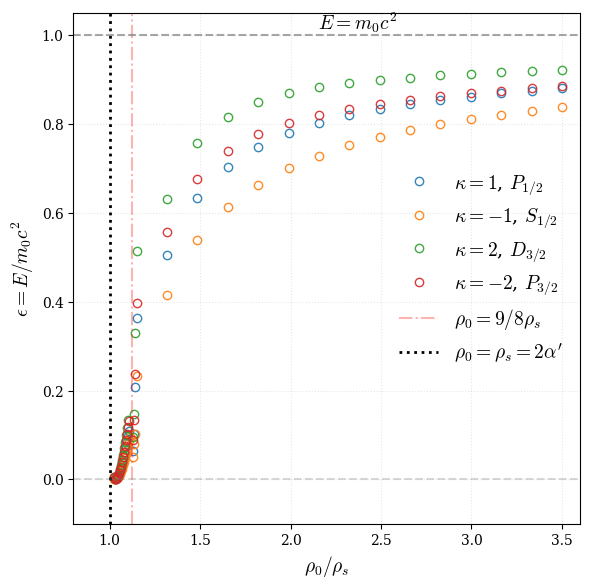

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Initialize figure and axes
fig, ax = plt.subplots(figsize=(6, 6)) # Increased figure width

# Define colors (assuming plt.cm.tab10 is the intended colormap)
colors = plt.cm.tab10.colors

for idx, k in enumerate(kappas):
    color = colors[idx % len(colors)]
    label_str = get_spectroscopy_label(k)

    # Extract valid data (Drop NaNs)
    valid_mask = ~np.isnan(df_energy12[f'kappa={k}'])
    x_valid = df_energy12.index[valid_mask].values
    y_valid = df_energy12[f'kappa={k}'][valid_mask].values

    sort_idx = np.argsort(x_valid)
    x_val = x_valid[sort_idx]
    y_val = y_valid[sort_idx]

    ax.plot(x_val, y_val, marker='o', linestyle='None', alpha=0.9, markerfacecolor='none', markeredgecolor=color, label=label_str)

# Vertical boundary markers
ax.axvline(1.125, color='red', linestyle='-.', alpha=0.3, label=r"$\rho_0 = 9/8 \rho_s$")
ax.axvline(1.0, color='black', linestyle=':', linewidth=2, label=r"$\rho_0 = \rho_s=2\alpha^{\prime}$")
# Horizontal line at y=0
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.text( 2.15, 1.015, r'$E = m_0c^2$', rotation=0, color='black', fontsize=14)
# Axes formatting
ax.set_xlabel(r"$\rho_0 / \rho_s$", fontsize=14)
ax.set_ylabel(r"$\epsilon=E/m_0 c^2$", fontsize=14)

ax.set_xlim(0.8, max(r0_over_rs) + 0.1)
ax.set_ylim(-0.1, 1.05)

ax.legend(loc='center right', fontsize=14, frameon=False, shadow=False)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

## $\kappa = \pm3,\pm4, \pm5,\pm10$

Initiating Continuation Sweep for rho_0 / rho_s ...

Processing κ = 3...
rho_0/rho_s = 3.5000 | Energy = 0.956864
rho_0/rho_s = 3.3321 | Energy = 0.956326
rho_0/rho_s = 3.1643 | Energy = 0.955753
rho_0/rho_s = 2.9964 | Energy = 0.955121
rho_0/rho_s = 2.8286 | Energy = 0.954405
rho_0/rho_s = 2.6607 | Energy = 0.953678
rho_0/rho_s = 2.4929 | Energy = 0.952750
rho_0/rho_s = 2.3250 | Energy = 0.951640
rho_0/rho_s = 2.1571 | Energy = 0.950130
rho_0/rho_s = 1.9893 | Energy = 0.947825
rho_0/rho_s = 1.8214 | Energy = 0.943389
rho_0/rho_s = 1.6536 | Energy = 0.931669
rho_0/rho_s = 1.4857 | Energy = 0.892904
rho_0/rho_s = 1.3179 | Energy = nan
rho_0/rho_s = 1.1500 | Energy = 0.953138
rho_0/rho_s = 1.1400 | Energy = 0.905279
rho_0/rho_s = 1.1346 | Energy = 0.859551
rho_0/rho_s = 1.1292 | Energy = 0.823063
rho_0/rho_s = 1.1237 | Energy = nan
rho_0/rho_s = 1.1183 | Energy = 0.952780
rho_0/rho_s = 1.1129 | Energy = 0.905956
rho_0/rho_s = 1.1075 | Energy = nan
rho_0/rho_s = 1.1021 | Energy = 0.954351

,kappa=3,kappa=-3,kappa=4,kappa=-4,kappa=5,kappa=-5,kappa=10,kappa=-10
r0/rs,,,,,,,,
3.500000,0.956864,0.959904,0.976377,0.973641,0.986285,0.981827,0.995950,0.994872
3.332143,0.956326,0.927113,0.976428,0.973641,0.986285,0.981827,0.995950,0.997405
3.164286,0.955753,0.925141,0.976455,0.973641,0.986285,0.981827,0.995950,0.997405
2.996429,0.955121,0.922959,0.976203,0.973641,0.986285,0.981827,0.995950,0.997405
2.828571,0.954405,0.920511,0.976200,0.973641,0.986285,0.981827,0.995950,0.997405
2.660714,0.953678,0.917720,0.976336,0.973641,0.986285,0.981827,0.995950,0.997405
2.492857,0.952750,0.914438,0.976338,0.973641,0.986285,0.981827,0.995950,0.997405
2.325000,0.951640,0.910440,0.976340,0.973641,0.986285,0.981828,0.995950,0.997405
2.157143,0.950130,0.905314,0.976344,0.973641,0.986285,0.981828,0.995950,0.997405


Table saved to /content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/dirac_energies_kappa45.csv


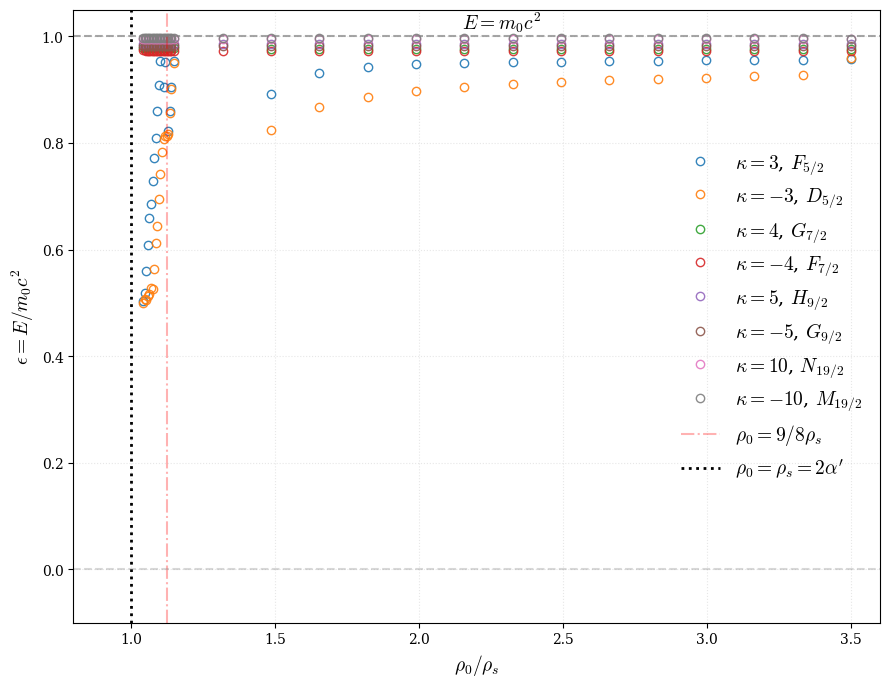

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from IPython.display import display
from scipy.interpolate import interp1d
import os # Import the os module for directory operations

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# --- Physical Parameters ---
alpha_prime = 1.0
#kappas = [1, -1, 2, -2, 4, -4, 5, -5, 10, -10]
kappas = [3, -3, 4,-4, 5, -5, 10, -10]
rho_s = 2 * alpha_prime

# --- The Generalized ODE System ---
def dirac_system(rho, psi, epsilon, rho_0, kappa):
    G, F = psi
    # INTERIOR SCHWARZSCHILD METRIC
    if rho <= rho_0:
        g11 = 1.0 / (1.0 - (rho_s * rho**2) / (rho_0**3))

        # --- to evaluate Buchdahl Limit ---
        if rho_0 <= (9.0 / 8.0) * rho_s:
            # Soffel's Analytical Continuation
            b = 1.0 / (rho_0**2 * (rho_0 / alpha_prime - 2.0))
            a = (1.0 - rho_s / rho_0) * np.exp(-b * rho_0**2)
            g00 = a * np.exp(b * rho**2)
        else:
            # Standard Constant-Density Interior
            term1 = (3/2) * np.sqrt(1.0 - rho_s / rho_0)
            term2 = (1/2) * np.sqrt(1.0 - (rho_s * rho**2) / (rho_0**3))
            g00 = (term1 - term2)**2

    # EXTERIOR SCHWARZSCHILD METRIC
    else:
        g11 = 1.0 / (1.0 - rho_s / rho)
        g00 = 1.0 - rho_s / rho

    sqrt_g11 = np.sqrt(g11)
    sqrt_g00 = np.sqrt(g00)
    dG_drho = -sqrt_g11 * (kappa / rho) * G + sqrt_g11 * (1.0 + epsilon / sqrt_g00) * F
    dF_drho =  sqrt_g11 * (kappa / rho) * F + sqrt_g11 * (1.0 - epsilon / sqrt_g00) * G
    return [dG_drho, dF_drho]

# Inner Boundary Condition
def outward_conditions(rho_min, epsilon, rho_0, kappa):
    g11 = 1
    if rho_0 <= (9/8) * rho_s:
        # Metric
        b = 1 / (rho_0**2 * (rho_0 / alpha_prime - 2.0))
        g00 = (1 - rho_s / rho_0) * np.exp(-b * rho_0**2)

        # Safety catch for floating-point underflow in deep relativistic regime
        if g00 < 1e-250:
            return [0.0, 0.0]

        R_center = np.sqrt(g00)
    else:
        # Metric
        term1 = (3/2) * np.sqrt(1.0 - rho_s / rho_0)
        term2 = (1/2)
        g00 = (term1 - term2)**2
        R_center = np.sqrt(g00)

    # Frobenius Expansion depending on kappa
    if kappa < 0:
        G_out_init = rho_min**np.abs(kappa)
        F_out_init = (1 / (2*np.abs(kappa) + 1)) * (1 - epsilon / R_center) * rho_min**(np.abs(kappa) + 1)
    else:
        G_out_init = (1 / (2*kappa + 1)) * (1 + epsilon / R_center) * rho_min**(kappa + 1)
        F_out_init = rho_min**kappa

    return [G_out_init, F_out_init]

# Outer Boundary Condition (Decay at infinity)
def inward_conditions(rho_max, epsilon, rho_0):
    G_in_init = 1e-6
    F_in_init = -np.sqrt((1 - epsilon) / (1 + epsilon)) * G_in_init
    return [G_in_init, F_in_init]

# --- Wronskian Mismatch Engine ---
def energy_mismatch(epsilon, rho_0, kappa):
    rho_min = 1e-7  # Center of the star

    # Matching Point dinamis
    # Pastikan selalu mencocokkan gelombang di luar bintang. Semakin tinggi kappa,
    # rintangan sentrifugal makin mendorong gelombang keluar, jadi titik temu ikut keluar.
    rho_match = max(rho_0 + 2.0, 15.0 + 1.5 * abs(kappa))

    # Radius infinity (rho_max) juga ikut didorong ke luar
    # agar ekor gelombang kappa tinggi tidak terpotong sebelum waktunya meluruh.
    rho_max = max(150.0, rho_match + 80.0)
    # rho_max = 150.0 # Spatial infinity
    # rho_match = rho_0 + 5.0 # Match slightly outside the star

    # --- ODE STIFFNESS PROTECTION ---
    # compute g00 in the center of the star to check extremeness redshift
    if rho_0 <= (9/8) * rho_s:
        b = 1 / (rho_0**2 * (rho_0 / alpha_prime - 2.0))
        g00_center = (1 - rho_s / rho_0) * np.exp(-b * rho_0**2)
    else:
        g00_center = ((3/2) * np.sqrt(1.0 - rho_s / rho_0) - 1/2)**2

    # SAFETY VALVE: Jika tebakan energi terlalu besar dibanding g00, gelombang
    # akan berosilasi miliaran kali. Langsung batalkan untuk mencegah infinite loop!
    if epsilon / np.sqrt(g00_center + 1e-300) > 2000.0:
        raise ValueError("Stiff ODE Triggered: Epsilon is non-physical for this deep metric.")
    # ----------------------------------------

    psi_out_init = outward_conditions(rho_min, epsilon, rho_0, kappa)
    psi_in_init = inward_conditions(rho_max, epsilon, rho_0)

    # Outward Integration
    psi_out = solve_ivp(
        dirac_system, [rho_min, rho_match], psi_out_init,
        args=(epsilon, rho_0, kappa), method='Radau',
        rtol=1e-8, atol=1e-10
    )
    # Inward Integration
    psi_in = solve_ivp(
        dirac_system, [rho_max, rho_match], psi_in_init,
        args=(epsilon, rho_0, kappa), method='RK45',
        rtol=1e-8, atol=1e-10
    )

    G_out, F_out = psi_out.y[:, -1]
    G_in, F_in   = psi_in.y[:, -1]

    return G_out * F_in - F_out * G_in

# Dynamic Bracket Finder
def find_bracket(rho_0, kappa, eps_start, eps_end, steps):
    eps_vals = np.linspace(eps_start, eps_end, steps)
    prev_E = None
    prev_val = None

    for val in eps_vals:
        try:
            curr_E = energy_mismatch(val, rho_0, kappa)
            # Jika temukan perubahan tanda, kirim rentangnya
            if prev_E is not None and curr_E * prev_E < 0:
                return [prev_val, val]
            prev_E = curr_E
            prev_val = val
        except ValueError:
            # Jika ditolak oleh Safety Valve (Stiffness Protection), langsung lompati
            prev_E = None
            continue
        except Exception:
            prev_E = None
            continue
    return None

# --- Spectroscopy label Generator ---
def get_spectroscopy_label(kappa):
    """Maps Dirac quantum number kappa to standard atomic L_j states."""
    l = kappa if kappa > 0 else abs(kappa) - 1
    j_num = 2 * abs(kappa) - 1  # Numerator for j = num/2
    letters = "SPDFGHIKLMN"
    L_str = letters[l] if l < len(letters) else str(l)
    return rf"$\kappa={kappa}$, ${L_str}_{{{j_num}/2}}$"

# --- Main Execution ---
print("Initiating Continuation Sweep for rho_0 / rho_s ...")
results_dict = {}

# Buat Base Array
r0_array_base = np.concatenate([
    np.linspace(3.5 * rho_s, 1.15 * rho_s, 15),     # Grid longgar untuk Newton/Weak limit
    np.linspace(1.14 * rho_s, 1.01 * rho_s, 25)     # Grid rapat untuk Relativistic limit
])
r0_over_rs = r0_array_base / rho_s

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10.colors

for k in kappas:
    print(f"\nProcessing κ = {k}...")
    k_energies = []

    search_max = 0.9999
    # Mencegah deteksi 'False Star-Interior State'.
    # Momentum sudut (|kappa|) tinggi energi aslinya menduduki nilai sangat dekat ke 1.0
    # Jangan cari sampai 1e-6, nanti program menyangkut di energi interior bintang!
    search_min = 0.7000 if abs(k) < 3 else 0.9500
    current_steps = 150

    for r0 in r0_array_base: # Iterasi menggunakan array murni (r0_array_base)
        bracket = find_bracket(r0, k, search_min, search_max, steps=current_steps)

        if bracket:
            res = root_scalar(
                energy_mismatch,
                args=(r0, k),
                bracket=bracket,
                method='brentq')

            E = res.root if res.converged else np.nan
        else:
            E = np.nan

        k_energies.append(E)
        print(f"rho_0/rho_s = {r0/rho_s:.4f} | Energy = {E:.6f}")

        if not np.isnan(E):
            search_max = min(0.9999, E + 0.005)
            search_min = max(0.5000, E - 0.050)
            current_steps = 30
        else:
            # Jika gagal, kembalikan ke batas pencarian aman (Safe Fallback)
            search_max = 0.9999
            search_min = 0.7000 if abs(k) < 3 else 0.9500
            current_steps = 150

    results_dict[f'kappa={k}'] = k_energies

# --- Finalize Results ---
df_energy = pd.DataFrame(results_dict, index=r0_over_rs)
df_energy.index.name = 'r0/rs'
display(df_energy.style.format("{:.6f}", na_rep="N/A").background_gradient(cmap='viridis', axis=None))

save_path = '/content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/dirac_energies_kappa45.csv'
# Create the directory if it does not exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)
df_energy.to_csv(save_path)
print(f"Table saved to {save_path}")

for idx, k in enumerate(kappas):
    color = colors[idx % len(colors)]
    label_str = get_spectroscopy_label(k)

    # Extract valid data (Drop NaNs)
    valid_mask = ~np.isnan(df_energy[f'kappa={k}'])
    x_valid = df_energy.index[valid_mask].values
    y_valid = df_energy[f'kappa={k}'][valid_mask].values

    sort_idx = np.argsort(x_valid)
    x_val = x_valid[sort_idx]
    y_val = y_valid[sort_idx]

    ax.plot(x_val, y_val, marker='o', linestyle='None', alpha=0.9, markerfacecolor='none', markeredgecolor=color, label=label_str)

# Vertical boundary markers
ax.axvline(1.125, color='red', linestyle='-.', alpha=0.3, label=r"$\rho_0 = 9/8 \rho_s$")
ax.axvline(1.0, color='black', linestyle=':', linewidth=2, label=r"$\rho_0 = \rho_s=2\alpha^{\prime}$")
# Horizontal line at y=0
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.text( 2.15, 1.015, r'$E = m_0c^2$', rotation=0, color='black', fontsize=14)
# Axes formatting
ax.set_xlabel(r"$\rho_0 / \rho_s$", fontsize=14)
ax.set_ylabel(r"$\epsilon=E/m_0 c^2$", fontsize=14)

ax.set_xlim(0.8, max(r0_over_rs) + 0.1)
ax.set_ylim(-0.1, 1.05)

ax.legend(loc='center right', fontsize=14, frameon=False, shadow=False)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()





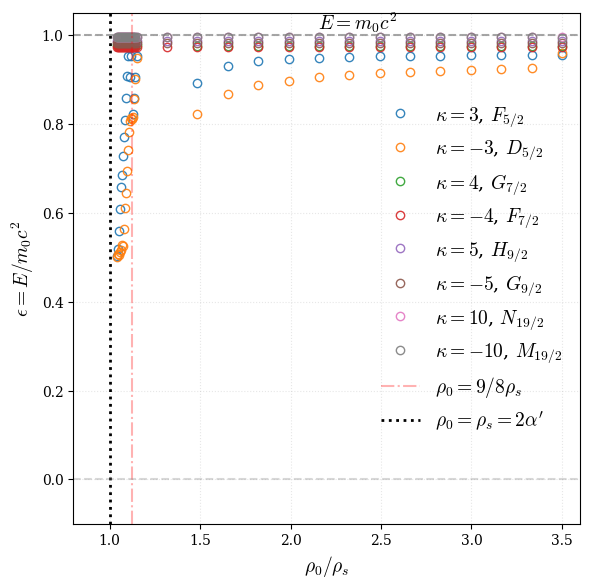

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Initialize figure and axes
fig, ax = plt.subplots(figsize=(6, 6)) # Increased figure width

# Define colors (assuming plt.cm.tab10 is the intended colormap)
colors = plt.cm.tab10.colors

for idx, k in enumerate(kappas):
    color = colors[idx % len(colors)]
    label_str = get_spectroscopy_label(k)

    # Extract valid data (Drop NaNs)
    valid_mask = ~np.isnan(df_energy[f'kappa={k}'])
    x_valid = df_energy.index[valid_mask].values
    y_valid = df_energy[f'kappa={k}'][valid_mask].values

    sort_idx = np.argsort(x_valid)
    x_val = x_valid[sort_idx]
    y_val = y_valid[sort_idx]

    ax.plot(x_val, y_val, marker='o', linestyle='None', alpha=0.9, markerfacecolor='none', markeredgecolor=color, label=label_str)

# Vertical boundary markers
ax.axvline(1.125, color='red', linestyle='-.', alpha=0.3, label=r"$\rho_0 = 9/8 \rho_s$")
ax.axvline(1.0, color='black', linestyle=':', linewidth=2, label=r"$\rho_0 = \rho_s=2\alpha^{\prime}$")
# Horizontal line at y=0
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.text( 2.15, 1.015, r'$E = m_0c^2$', rotation=0, color='black', fontsize=14)
# Axes formatting
ax.set_xlabel(r"$\rho_0 / \rho_s$", fontsize=14)
ax.set_ylabel(r"$\epsilon=E/m_0 c^2$", fontsize=14)

ax.set_xlim(0.8, max(r0_over_rs) + 0.1)
ax.set_ylim(-0.1, 1.05)

ax.legend(loc='center right', fontsize=14, frameon=False, shadow=False)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import os

# Define the CSV file path
csv_file_path = '/content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/dirac_energies_kappa45.csv'

# Read the CSV file into a pandas DataFrame
df_from_csv = pd.read_csv(csv_file_path)

# Define the output Excel file path
excel_file_path = '/content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/dirac_energies_kappa45.xlsx'

# Create the directory if it does not exist
os.makedirs(os.path.dirname(excel_file_path), exist_ok=True)

# Save the DataFrame to an Excel file
df_from_csv.to_excel(excel_file_path, index=False)

print(f"CSV file '{csv_file_path}' successfully converted to Excel file '{excel_file_path}'.")

CSV file '/content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/dirac_energies_kappa45.csv' successfully converted to Excel file '/content/drive/MyDrive/OszavlaDrive/Dokumen/Data_Komputasi/dirac_energies_kappa45.xlsx'.


In [ ]:
import pandas as pd
import os

# Define the input CSV file path
csv_file_path = '/content/drive/MyDrive/OTSAVLA/RESEARCH/dirac_energies_kappa12.csv'

# Define the output Excel file path
excel_file_path = '/content/drive/MyDrive/OTSAVLA/RESEARCH/dirac_energies_kappa12.xlsx'

# Read the CSV file into a pandas DataFrame
df_csv = pd.read_csv(csv_file_path)

# Save the DataFrame to an Excel file
# Ensure the directory exists before saving
os.makedirs(os.path.dirname(excel_file_path), exist_ok=True)
df_csv.to_excel(excel_file_path, index=False)

print(f'Successfully converted {csv_file_path} to {excel_file_path}')

Successfully converted /content/drive/MyDrive/OTSAVLA/RESEARCH/dirac_energies_kappa12.csv to /content/drive/MyDrive/OTSAVLA/RESEARCH/dirac_energies_kappa12.xlsx


In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive"
NOTEBOOK_PATH = "/content/drive/MyDrive/Colab Notebooks/Koneksi_Affine_Spinor.ipynb"

!jupyter nbconvert --to latex "{NOTEBOOK_PATH}" --output-dir="{OUTPUT_DIR}"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Koneksi_Affine_Spinor.ipynb to latex
[NbConvertApp] Writing 163309 bytes to /content/drive/MyDrive/Koneksi_Affine_Spinor.tex


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
